<a href="https://colab.research.google.com/github/munasafad77-blip/Hydroponic_Optimizer/blob/main/MUNA_uma_catalysis_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI for Accelerated Materials Science: ML Potentials for Catalyst Discovery

**CCAI Virtual Summer School 2026**

This notebook is the adaptation of the FAIR Chemistry
**UMA Catalysis Tutorial**. It preserves the original scientific workflow,
theory, equations, interpretation, exercises, troubleshooting advice, and
caveats while integrating climate relevance, computational-emissions tracking,
and responsible-use guidance.

**Original tutorial:** https://fair-chem.github.io/uma-catalysis-tutorial/

**Original paper:** B. Kreitz et al., *The Journal of Physical Chemistry C*
(2021), https://doi.org/10.1021/acs.jpcc.0c09985

> **Important:** Access to the `facebook/UMA` model is gated through Hugging
> Face. Request access before running the notebook and use a token with
> permission to read public gated repositories.


The default configuration follows the full tutorial. `FAST_MODE=True` is an
optional CCAI classroom setting that deliberately reduces sampling and
optimization effort; its results should not be compared directly with the
published reference values.


# Table of contents

1. [Overview and learning objectives](#overview)
2. [Climate relevance](#climate-relevance)
3. [Installation and Hugging Face setup](#installation)
4. [Imports, configuration, and reproducibility](#configuration)
5. [Start computational-emissions tracking](#codecarbon-start)
6. [Load UMA-S-1P2](#load-uma)
7. [Part 1: Bulk crystal optimization](#part-1)
8. [Part 2: Surface energy calculations](#part-2)
9. [Part 3: Wulff construction](#part-3)
10. [Part 4: H adsorption with ZPE](#part-4)
11. [Part 5: Coverage-dependent H adsorption](#part-5)
12. [Part 6: CO thermochemistry and NEB](#part-6)
13. [Summary and best practices](#summary)
14. [Troubleshooting](#troubleshooting)
15. [Caveats and pitfalls](#caveats)
16. [Computational-emissions estimate](#codecarbon-stop)
17. [Model card and responsible use](#responsible-use)
18. [References](#references)


<a name="overview"></a>
# Overview and learning objectives

This tutorial demonstrates how to use the Universal Model for Atoms (UMA)
machine-learning potential for comprehensive catalyst-surface analysis. It
reproduces the principal computational workflow from *Microkinetic Modeling
of CO₂ Desorption from Supported Multifaceted Ni Catalysts*, showing how an ML
potential can accelerate common computational-catalysis calculations.

By the end of the tutorial, you will be able to:

- optimize a bulk crystal and extract its equilibrium lattice constant;
- calculate surface energies by linear extrapolation over slab thickness;
- construct a Wulff shape and interpret nanoparticle morphology;
- calculate adsorption energies with dispersion and zero-point corrections;
- study coverage-dependent binding and lateral interactions;
- calculate a reaction pathway and activation barrier using NEB;
- choose appropriate UMA tasks and recognize important limitations;
- distinguish screening predictions from results requiring DFT or experimental validation.

## About UMA-S-1P2

UMA-S-1P2 is a universal machine-learning potential trained using several
materials and molecular datasets, including OMat24, OC20, OMol25, ODAC23, and
OMC25. It can provide a large speed improvement over DFT and is valuable for
screening, but it is not a substitute for validation when quantitative
accuracy is consequential.

The tutorial uses two UMA chemistry-specific task contexts:

- `task_name="omat"` for bulk structures and clean surfaces;
- `task_name="oc20"` for adsorbate–surface chemistry.


<a name="climate-relevance"></a>
# Climate relevance

Catalysts and advanced materials are important to low-carbon fuels, CO₂
conversion, green hydrogen, ammonia synthesis, industrial decarbonization,
batteries, and energy-conversion systems. ML potentials can accelerate early
screening by allowing researchers to examine more candidate structures than
would normally be practical with DFT alone.

Faster prediction does not by itself produce climate benefit. Promising
materials still require domain review, higher-fidelity calculation,
experimental validation, safety assessment, life-cycle analysis, and
consideration of cost, supply chains, scale-up, and deployment context. This
notebook therefore treats UMA as a screening and teaching tool.


<a name="installation"></a>
# Installation and Hugging Face setup

The tutorial uses:

- `ase` for atomistic structures and optimizers;
- `fairchem-core` for UMA inference;
- `fairchem-data-oc` and `fairchem-applications-cattsunami` for catalyst-surface tools;
- `pymatgen` for surface construction and Wulff analysis;
- `matplotlib` and `numpy` for analysis and visualization;
- `torch-dftd` for D3 dispersion corrections;
- `x3dase` for interactive structure viewing;
- `codecarbon` for computational-emissions estimation.

Installation can take several minutes in a fresh Colab runtime.


In [52]:
# Colab setup
# Run this cell first. Installation can take a few minutes.

!pip -q install "fairchem-core[docs]" fairchem-data-oc fairchem-applications-cattsunami x3dase
!pip -q install ase pymatgen matplotlib numpy codecarbon torch-dftd huggingface_hub

print("Installation complete.")


Installation complete.


## Hugging Face access

1. Create a Hugging Face account.
2. Request access at https://huggingface.co/facebook/UMA.
3. Create a token at https://huggingface.co/settings/tokens/.
4. Give the token permission to read public gated repositories you can access.
5. Enter the token securely when prompted below.

Never paste a real token directly into the saved notebook source.


In [58]:
from huggingface_hub import login
from google.colab import userdata

# Ensure your Hugging Face token is stored in Colab's Secrets manager
# under the name 'HF_TOKEN' and that notebook access is enabled.

try:
    # Attempt to retrieve the token from Colab secrets
    hf_token = userdata.get('HF_TOKEN')
    if hf_token:
        login(token=hf_token)
        print("Successfully logged into Hugging Face Hub using Colab secrets.")
    else:
        print("HF_TOKEN secret not found or empty. Please ensure it's set correctly.")
except Exception as e:
    print(f"An error occurred during login: {e}")
    print("Please verify your HF_TOKEN is correctly set in Colab secrets and retry.")

An error occurred during login: Secret HF_TOKEN does not exist.
Please verify your HF_TOKEN is correctly set in Colab secrets and retry.


In [47]:
from huggingface_hub import login

print("Please paste your Hugging Face token below and press Enter:")
login()

Please paste your Hugging Face token below and press Enter:


In [62]:
from huggingface_hub import HfApi

api = HfApi()
if api.whoami():
    print(f"You are logged in as: {api.whoami()['name']}")
else:
    print("You are not logged in to Hugging Face.")

You are logged in as: Muna77


In [63]:
from google.colab import userdata

try:
    # Attempt to retrieve the HF_TOKEN
    hf_token = userdata.get('HF_TOKEN')

    if hf_token is not None:
        print("HF_TOKEN found in Colab secrets. Now verifying access...")
        # If we reached here, userdata.get() didn't raise SecretNotFoundError
        # We can assume it's accessible if no other error occurs below.
        print("HF_TOKEN is accessible to this notebook.")
        print("You can now try running the Hugging Face login cell again.")
    else:
        print("HF_TOKEN is not found in Colab secrets or is empty.")
        print("Please ensure you've added it correctly via the '🔑' icon in the left panel and enabled 'Notebook access'.")
except Exception as e:
    # This catches NotebookAccessError or other unexpected errors
    print(f"An error occurred while trying to access HF_TOKEN: {e}")
    print("Please ensure 'HF_TOKEN' is added in Colab secrets and 'Notebook access' is enabled for it.")

An error occurred while trying to access HF_TOKEN: Secret HF_TOKEN does not exist.
Please ensure 'HF_TOKEN' is added in Colab secrets and 'Notebook access' is enabled for it.


In [50]:
from huggingface_hub import login
from google.colab import userdata

# You can store your Hugging Face token in Colab's Secrets manager
# under the name 'HF_TOKEN'.
# Click the '🔑' icon in the left panel to manage secrets.

try:
    # Attempt to retrieve the token from Colab secrets
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    print("Successfully logged into Hugging Face Hub using Colab secrets.")
except Exception as e:
    print(f"Could not log in using Colab secrets. Please ensure 'HF_TOKEN' is set: {e}")
    print("You may need to manually run `huggingface_hub.login()` and paste your token.")
    # Optionally, if you want a manual prompt if secrets fail:
    # login() # This will prompt you to paste your token

Could not log in using Colab secrets. Please ensure 'HF_TOKEN' is set: Secret HF_TOKEN does not exist.
You may need to manually run `huggingface_hub.login()` and paste your token.


In [51]:
from huggingface_hub import login
from google.colab import userdata

try:
    # Retrieve your Hugging Face token from Colab secrets
    hf_token = userdata.get('HF_TOKEN')

    # Check if the token was successfully retrieved
    if hf_token:
        login(token=hf_token)
        print("Successfully logged into Hugging Face Hub using the HF_TOKEN secret.")
    else:
        print("HF_TOKEN secret not found or empty. Please ensure it's set correctly.")
except Exception as e:
    print(f"An error occurred during login: {e}")

An error occurred during login: Secret HF_TOKEN does not exist.


<a name="configuration"></a>
# Imports, configuration, and reproducibility

`FAST_MODE=False` preserves the full tutorial settings. Set it to `True` only
for a short classroom demonstration. Random seeds are set to make sampling as
repeatable as the underlying libraries permit; generated configurations may
still differ across package versions and hardware.


In [53]:
# Imports, configuration, and reproducibility

from pathlib import Path
import os
import random

import numpy as np
import matplotlib.pyplot as plt
import torch

import ase
import ase.io
from ase import Atoms
from ase.build import bulk
from ase.optimize import FIRE, LBFGS
from ase.vibrations import Vibrations
from ase.visualize import view

import fairchem.core
from fairchem.core import FAIRChemCalculator, pretrained_mlip
from fairchem.data.oc.core import (
    Adsorbate,
    AdsorbateSlabConfig,
    Bulk,
    MultipleAdsorbateSlabConfig,
    Slab,
)

import importlib.metadata
import pymatgen
from pymatgen.analysis.wulff import WulffShape
from pymatgen.core.surface import SlabGenerator
from pymatgen.io.ase import AseAtomsAdaptor

from torch_dftd.torch_dftd3_calculator import TorchDFTD3Calculator

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

output_dir = Path("ccai_uma_catalysis_results")
output_dir.mkdir(exist_ok=True)

part_dirs = {
    "part1": "part1-bulk-optimization",
    "part2": "part2-surface-energies",
    "part3": "part3-wulff-construction",
    "part4": "part4-h-adsorption",
    "part5": "part5-coverage-dependence",
    "part6": "part6-co-reaction-barrier",
}

for dirname in part_dirs.values():
    (output_dir / dirname).mkdir(exist_ok=True)

for facet in ["111", "100", "110", "211"]:
    (output_dir / part_dirs["part2"] / f"ni{facet}").mkdir(exist_ok=True)

# CCAI teaching option. False reproduces the full tutorial settings.
FAST_MODE = False

if FAST_MODE:
    num_sites = 2
    relaxation_steps = 20
    neb_steps = 10
    n_images = 3
    print("WARNING: FAST_MODE reduces sampling and optimization effort.")
    print("Do not compare fast-mode results directly with published reference values.")
else:
    num_sites = 5
    relaxation_steps = 300
    neb_steps = 300
    n_images = 10

print(f"FAST_MODE = {FAST_MODE}")
print(f"num_sites = {num_sites}")
print(f"relaxation_steps = {relaxation_steps}")
print(f"neb_steps = {neb_steps}, intermediate NEB images = {n_images}")
print("fairchem-core:", fairchem.core.__version__)
print("ASE:", ase.__version__)
print("NumPy:", np.__version__)
print("pymatgen:", importlib.metadata.version("pymatgen"))
print("PyTorch:", torch.__version__)


FAST_MODE = False
num_sites = 5
relaxation_steps = 300
neb_steps = 300, intermediate NEB images = 10
fairchem-core: 2.22.0
ASE: 3.29.0
NumPy: 2.1.3
pymatgen: 2026.5.4
PyTorch: 2.13.0+cu130


<a name="codecarbon-start"></a>
# Start computational-emissions tracking

One tracker is placed around the complete scientific workflow, from UMA model
loading to the end of Part 6. It excludes package installation and authentication but can
include time spent reading or pausing between cells.

CodeCarbon estimates operational energy use and CO₂-equivalent emissions. It
does not include UMA training, hardware manufacture, data-center construction,
or the full lifecycle footprint of the computation.


In [57]:
# Start emissions tracking

from codecarbon import EmissionsTracker

# Stop an existing tracker if this cell is rerun.
if "tracker" in globals() and tracker is not None:
    try:
        tracker.stop()
    except Exception:
        pass

tracker = EmissionsTracker(
    project_name="ccai-uma-catalysis-tutorial",
    output_dir=str(output_dir),
    output_file="emissions.csv",
    save_to_file=True,
)
tracker.start()

print("CodeCarbon tracking started.")
print("Tracked scope: UMA model loading and the complete Parts 1–6 workflow.")


[codecarbon INFO @ 22:49:38] Energy consumed for RAM : 0.000365 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:49:38] Energy consumed for all GPUs : 0.000434 kWh. Total GPU Power : 11.877692931393764 W
[codecarbon INFO @ 22:49:38] Delta energy consumed for CPU with cpu_load : 0.000003 kWh, power : 0.8944018556923078 W
[codecarbon INFO @ 22:49:38] Energy consumed for All CPU : 0.000042 kWh
[codecarbon INFO @ 22:49:38] 0.000841 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 22:49:38] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 22:49:38] Emissions data (if any) will be saved to file /content/ccai_uma_catalysis_results/emissions.csv
[codecarbon INFO @ 22:49:38] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 22:49:38] >>> Tracker's metadata:
[codecarbon INFO @ 22:49:38]   Platform system: Linux-6.6.122+-x86_64-with-glibc2.35
[codecarbon INFO @ 22:49:38]   Python version: 3.

CodeCarbon tracking started.
Tracked scope: UMA model loading and the complete Parts 1–6 workflow.


<a name="load-uma"></a>
# Load UMA-S-1P2

The first model load may take additional time because the checkpoint must be
downloaded and the model may be compiled. If access fails, confirm that access
to `facebook/UMA` has been granted and that `HF_TOKEN` contains a valid token.


In [64]:
# Load the UMA-S-1P2 model

print("Loading UMA-S-1P2 model...")
predictor = pretrained_mlip.get_predict_unit("uma-s-1p2")
print("Model loaded successfully.")

Loading UMA-S-1P2 model...


checkpoints/uma-s-1p2.pt: reconstructing file:   0%|          |  0.00B / 2.33GB            

checkpoints/uma-s-1p2.pt: downloading bytes:           |  0.00B            

[codecarbon INFO @ 22:51:08] Energy consumed for RAM : 0.000250 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:51:08] Energy consumed for all GPUs : 0.000300 kWh. Total GPU Power : 12.14225144685297 W
[codecarbon INFO @ 22:51:08] Delta energy consumed for CPU with cpu_load : 0.000020 kWh, power : 4.759629304850001 W
[codecarbon INFO @ 22:51:08] Energy consumed for All CPU : 0.000049 kWh
[codecarbon INFO @ 22:51:08] 0.000599 kWh of electricity and 0.000000 L of water were used since the beginning.


iso_atom_elem_refs.yaml:   0%|          | 0.00/9.00k [00:00<?, ?B/s]

form_elem_refs.yaml:   0%|          | 0.00/11.8k [00:00<?, ?B/s]

[codecarbon INFO @ 22:51:23] Energy consumed for RAM : 0.000292 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:51:23] Energy consumed for all GPUs : 0.000351 kWh. Total GPU Power : 12.114598451592599 W
[codecarbon INFO @ 22:51:23] Delta energy consumed for CPU with cpu_load : 0.000008 kWh, power : 1.80982239425 W
[codecarbon INFO @ 22:51:23] Energy consumed for All CPU : 0.000056 kWh
[codecarbon INFO @ 22:51:23] 0.000699 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 22:51:23] Unable to access geographical location through primary API. Will resort to using the backup API - Exception : Region is empty - url=https://get.geojs.io/v1/ip/geo.json


Model loaded successfully.


<a name="part-1"></a>
# Part 1: Bulk crystal optimization

## Introduction

Before studying surfaces, determine the equilibrium lattice constant of bulk
Ni. Surface energies and adsorption geometries depend on the underlying
lattice parameter, so a consistent relaxed bulk reference is essential.

## Theory

For FCC Ni, the lattice constant (a) defines the cubic unit-cell size. The
experimental room-temperature value is approximately (3.524\ \text{Å}).
The calculation relaxes both atomic positions and the cell so that UMA can
locate its equilibrium structure. The `omat` task is used because the state of
the system is bulk material without adsorbates.

The optimizer stops when the maximum force falls below `fmax` or when the
maximum number of relaxation steps is reached.


In [65]:
# Track emissions for the first main calculation
# Create initial FCC Ni structure
a_initial = 3.52  # Å, close to experimental
ni_bulk = bulk("Ni", "fcc", a=a_initial, cubic=True)

print(f"Initial lattice constant: {a_initial:.2f} Å")
print(f"Number of atoms: {len(ni_bulk)}")

calc = FAIRChemCalculator(predictor, task_name="omat")
ni_bulk.calc = calc

from ase.filters import ExpCellFilter

ecf = ExpCellFilter(ni_bulk)
opt = LBFGS(
    ecf,
    trajectory=str(output_dir / part_dirs["part1"] / "ni_bulk_opt.traj"),
    logfile=str(output_dir / part_dirs["part1"] / "ni_bulk_opt.log"),
)
opt.run(fmax=0.05, steps=relaxation_steps)

cell = ni_bulk.get_cell()
a_optimized = cell[0, 0]
a_exp = 3.524
error = abs(a_optimized - a_exp) / a_exp * 100

print("\n" + "=" * 50)
print(f"Experimental lattice constant: {a_exp:.3f} Å")
print(f"Optimized lattice constant:    {a_optimized:.3f} Å")
print(f"Relative error:                {error:.2f}%")
print("=" * 50)

ase.io.write(str(output_dir / part_dirs["part1"] / "ni_bulk_relaxed.cif"), ni_bulk)
a_opt = a_optimized


Initial lattice constant: 3.52 Å
Number of atoms: 4


/tmp/ipykernel_3147/1054530302.py:14: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  ecf = ExpCellFilter(ni_bulk)
[codecarbon INFO @ 22:51:38] Energy consumed for RAM : 0.000333 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:51:38] Energy consumed for all GPUs : 0.000404 kWh. Total GPU Power : 12.715293055660519 W
[codecarbon INFO @ 22:51:38] Delta energy consumed for CPU with cpu_load : 0.000007 kWh, power : 1.7565524589500001 W
[codecarbon INFO @ 22:51:38] Energy consumed for All CPU : 0.000063 kWh
[codecarbon INFO @ 22:51:38] 0.000800 kWh of electricity and 0.000000 L of water were used since the beginning.
W0907 22:51:41.225000 3147 torch/_logging/_internal.py:1345] [0/0] Profiler record function <class 'torch.autograd.profiler.record_function'> will be ignored
W0907 22:51:46.935000 3147 torch/_inductor/utils.py:1953] [3/0_1] Not enough SMs to use max_autotune_gemm mode
[codecarbon INFO @ 22:51:53] Energy consumed for RAM : 0.000375 kWh. RA


Experimental lattice constant: 3.524 Å
Optimized lattice constant:    3.507 Å
Relative error:                0.50%


## Understanding the result

The published tutorial obtained an optimized lattice constant near
(3.51\ \text{Å}), about 0.5% from the experimental value. Small differences
can arise from the underlying DFT functional, temperature (0 K calculation
versus room-temperature experiment), training-data coverage, and ML error.

For later parts, the ML-relaxed lattice constant should be used consistently.
Mixing an ML lattice constant with otherwise unrelated DFT reference energies
can introduce an avoidable inconsistency.

> **Source caution:** The original web page contains a sentence referring to
> “BCC Ni” in its comparison paragraph. Nickel here is FCC; the notebook uses
> the correct FCC structure.

## Explore on your own

1. Change `a_initial` to 3.0 or 4.0 Å. Does the same minimum emerge?
2. Tighten `fmax` from 0.05 to 0.01 eV/Å and compare the required steps.
3. Try `Cu`, `Pd`, or `Pt` and compare with experimental lattice constants.
4. Remove `cubic=True` and test whether the FCC structure remains stable.
5. Compare `omat` with `oc20` and explain why `omat` is preferred here.

> **Missing UMA access?** The original tutorial also provides an
> [example Ni bulk structure](https://fair-chem.github.io/example_configs/ni_bulk.xyz)
> that can be tested in the
> [public UMA demo](https://facebook-fairchem-uma-demo.hf.space/) without
> running the gated model locally.


<a name="part-2"></a>
# Part 2: Surface energy calculations

## Introduction

Surface energy (gamma) is the thermodynamic cost of creating a surface. It
controls relative facet stability and strongly influences equilibrium particle
morphology. We calculate Ni(111), Ni(100), Ni(110), and Ni(211).

## Theory

For a symmetric slab with two exposed surfaces,

$$
\gamma = \frac{E_{\mathrm{slab}} - N E_{\mathrm{bulk}}}{2A},
$$

where (E_{\mathrm{slab}}) is the slab energy, (N) is the number of atoms,
(E_{\mathrm{bulk}}) is the bulk energy per atom, and (A) is the area of one
surface. The factor of two accounts for the top and bottom surfaces.

Direct subtraction can be sensitive to numerical differences between bulk and
slab calculations. The tutorial therefore evaluates several slab thicknesses
and fits

$$E_{\mathrm{slab}} = mN + b.$$

The slope (m) is a fitted bulk energy per atom and the intercept (b=2A\gamma).
Linearity is also a convergence diagnostic: a visibly nonlinear relationship
suggests slabs that are too thin or calculations that are insufficiently
converged.


## Step 1: Setup and bulk energy reference

Define the facets and calculate the bulk reference energy per atom. This
independent value is later compared with the slope fitted from the slabs.


In [66]:
facets = [(1, 1, 1), (1, 0, 0), (1, 1, 0), (2, 1, 1)]
surface_energies = {}
surface_energies_SI = {}
all_fit_data = {}

E_bulk_total = ni_bulk.get_potential_energy()
N_bulk = len(ni_bulk)
E_bulk_per_atom = E_bulk_total / N_bulk

print("Bulk energy reference:")
print(f"  Total energy: {E_bulk_total:.2f} eV")
print(f"  Number of atoms: {N_bulk}")
print(f"  Energy per atom: {E_bulk_per_atom:.6f} eV/atom")


Bulk energy reference:
  Total energy: -21.98 eV
  Number of atoms: 4
  Energy per atom: -5.494851 eV/atom


## Step 2: Generate and relax slabs

Generate 4-, 6-, and 8-layer slabs for each facet in the full tutorial,
relax them with the `omat` task, and fit total energy against atom count.


In [67]:
adaptor = AseAtomsAdaptor()
ni_structure = adaptor.get_structure(ni_bulk)
thicknesses = [4, 6] if FAST_MODE else [4, 6, 8]

for facet in facets:
    facet_str = "".join(map(str, facet))
    print("\n" + "=" * 60)
    print(f"Calculating Ni({facet_str}) surface energy")
    print("=" * 60)

    n_atoms_list = []
    energies_list = []

    for n_layers in thicknesses:
        print(f"\n  Thickness: {n_layers} layers")

        slabgen = SlabGenerator(
            ni_structure,
            facet,
            min_slab_size=n_layers * a_opt / np.sqrt(sum([h**2 for h in facet])),
            min_vacuum_size=10.0,
            center_slab=True,
        )

        pmg_slab = slabgen.get_slabs()[0]
        slab = adaptor.get_atoms(pmg_slab)
        slab.center(vacuum=10.0, axis=2)

        print(f"    Atoms: {len(slab)}")

        calc = FAIRChemCalculator(predictor, task_name="omat")
        slab.calc = calc
        opt = LBFGS(slab, logfile=None)
        opt.run(fmax=0.05, steps=relaxation_steps)

        E_slab = slab.get_potential_energy()
        n_atoms_list.append(len(slab))
        energies_list.append(E_slab)

        print(f"    Energy: {E_slab:.2f} eV")

    coeffs = np.polyfit(n_atoms_list, energies_list, 1)
    slope = coeffs[0]
    intercept = coeffs[1]

    cell = slab.get_cell()
    area = np.linalg.norm(np.cross(cell[0], cell[1]))
    gamma = intercept / (2 * area)  # eV/Å²
    gamma_SI = gamma * 16.0218  # J/m²

    print("\n  Linear fit:")
    print(f"    Slope:     {slope:.6f} eV/atom (bulk reference: {E_bulk_per_atom:.6f})")
    print(f"    Difference: {slope - E_bulk_per_atom:+.6f} eV/atom")
    print(f"    Intercept: {intercept:.2f} eV")

    print("\n  Surface energy:")
    print(f"    gamma = {gamma:.6f} eV/Å² = {gamma_SI:.2f} J/m²")

    surface_energies[facet] = gamma
    surface_energies_SI[facet] = gamma_SI
    all_fit_data[facet] = {
        "n_atoms": n_atoms_list,
        "energies": energies_list,
        "slope": slope,
        "intercept": intercept,
    }



Calculating Ni(111) surface energy

  Thickness: 4 layers
    Atoms: 4
    Energy: -20.66 eV

  Thickness: 6 layers
    Atoms: 6
    Energy: -31.64 eV

  Thickness: 8 layers
    Atoms: 8
    Energy: -42.63 eV

  Linear fit:
    Slope:     -5.491985 eV/atom (bulk reference: -5.494851)
    Difference: +0.002867 eV/atom
    Intercept: 1.31 eV

  Surface energy:
    gamma = 0.122708 eV/Å² = 1.97 J/m²

Calculating Ni(100) surface energy

  Thickness: 4 layers
    Atoms: 8
    Energy: -42.15 eV

  Thickness: 6 layers
    Atoms: 12
    Energy: -64.13 eV

  Thickness: 8 layers
    Atoms: 16
    Energy: -86.11 eV

  Linear fit:
    Slope:     -5.494798 eV/atom (bulk reference: -5.494851)
    Difference: +0.000053 eV/atom
    Intercept: 1.80 eV

  Surface energy:
    gamma = 0.146725 eV/Å² = 2.35 J/m²

Calculating Ni(110) surface energy

  Thickness: 4 layers
    Atoms: 8
    Energy: -41.36 eV

  Thickness: 6 layers
    Atoms: 12
    Energy: -63.34 eV

  Thickness: 8 layers
    Atoms: 16
    En

## Step 3: Visualize the linear fits

Plot each slab-energy series and its fitted line. Inspecting the fit is part
of the convergence assessment, not merely a presentation step.


[codecarbon INFO @ 22:54:53] Energy consumed for RAM : 0.000872 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:54:53] Energy consumed for all GPUs : 0.002006 kWh. Total GPU Power : 30.062993674598008 W
[codecarbon INFO @ 22:54:53] Delta energy consumed for CPU with cpu_load : 0.000004 kWh, power : 0.9984340578500001 W
[codecarbon INFO @ 22:54:53] Energy consumed for All CPU : 0.000290 kWh
[codecarbon INFO @ 22:54:53] 0.003168 kWh of electricity and 0.000000 L of water were used since the beginning.


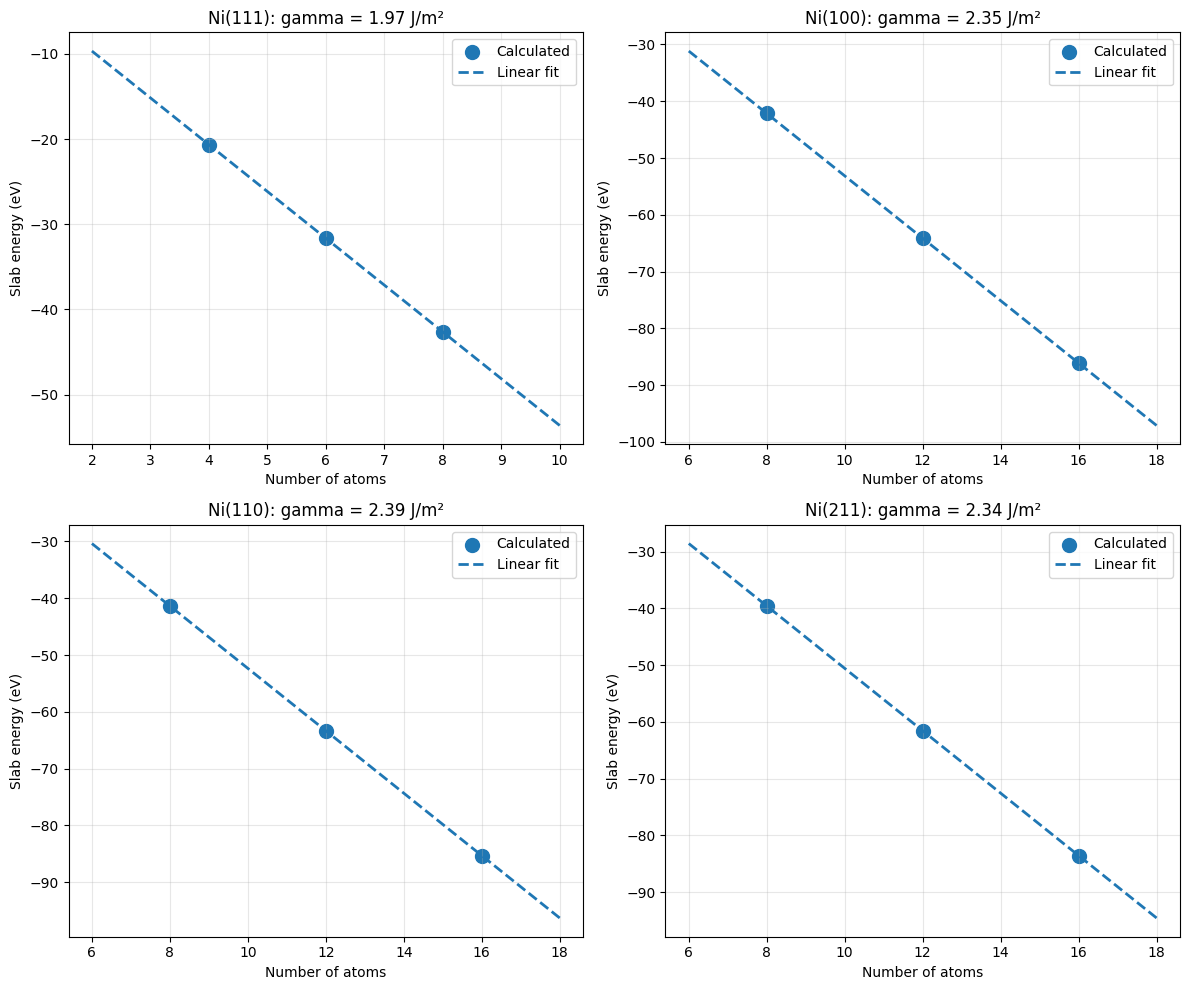

In [68]:
# Visualize the linear fits

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, facet in enumerate(facets):
    ax = axes[idx]
    data = all_fit_data[facet]

    ax.scatter(data["n_atoms"], data["energies"], s=100, marker="o", label="Calculated")

    n_range = np.linspace(min(data["n_atoms"]) - 2, max(data["n_atoms"]) + 2, 100)
    E_fit = data["slope"] * n_range + data["intercept"]
    ax.plot(n_range, E_fit, "--", linewidth=2, label="Linear fit")

    facet_str = f"Ni({facet[0]}{facet[1]}{facet[2]})"
    ax.set_xlabel("Number of atoms")
    ax.set_ylabel("Slab energy (eV)")
    ax.set_title(f"{facet_str}: gamma = {surface_energies_SI[facet]:.2f} J/m²")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(output_dir / part_dirs["part2"] / "surface_energy_fits.png"), dpi=200, bbox_inches="tight")
plt.show()


## Step 4: Compare with literature

Compare the calculated values with the DFT literature references used by the
source tutorial. The comparison reports relative differences but should not be
treated as a substitute for an independent convergence study.


In [69]:
lit_values = {
    (1, 1, 1): 1.92,
    (1, 0, 0): 2.21,
    (1, 1, 0): 2.29,
    (2, 1, 1): 2.24,
}

print("\nComparison with literature values:")
for facet in facets:
    facet_str = f"Ni({facet[0]}{facet[1]}{facet[2]})"
    calc_val = surface_energies_SI[facet]
    lit = lit_values[facet]
    diff = abs(calc_val - lit) / lit * 100
    print(f"{facet_str:<10} {calc_val:>8.2f} J/m²  (Literature: {lit:.2f}, diff={diff:.1f}%)")



Comparison with literature values:
Ni(111)        1.97 J/m²  (Literature: 1.92, diff=2.4%)
Ni(100)        2.35 J/m²  (Literature: 2.21, diff=6.4%)
Ni(110)        2.39 J/m²  (Literature: 2.29, diff=4.2%)
Ni(211)        2.34 J/m²  (Literature: 2.24, diff=4.5%)


## Interpretation and comparison

Published tutorial reference values were approximately:

| Facet | UMA tutorial | Literature value used on site |
|---|---:|---:|
| Ni(111) | 1.97 J/m² | 1.92 J/m² |
| Ni(100) | 2.35 J/m² | 2.21 J/m² |
| Ni(110) | 2.39 J/m² | 2.29 J/m² |
| Ni(211) | 2.34 J/m² | 2.24 J/m² |

The ordering is generally more reliable for screening than small differences
in absolute values. Check the fitted slope against the independently computed
bulk energy, inspect the linear plots, and perform thickness and vacuum
convergence tests before using the values quantitatively.

## Explore on your own

1. Add thicker slabs and check whether the fitted surface energy changes.
2. Increase the vacuum from 10 to 15 or 20 Å.
3. Compare relaxed and unrelaxed slabs.
4. Examine whether constraining central layers affects the result.
5. Add another low- or high-index facet and predict its Wulff contribution.


<a name="part-3"></a>
# Part 3: Wulff construction

## Introduction and theory

The Wulff construction predicts the equilibrium shape that minimizes total
surface free energy. For facet (i), the Wulff theorem gives

$$\frac{h_i}{\gamma_i}=\text{constant},$$

where (h_i) is the distance from the particle center to the facet plane and
(gamma_i) is its surface energy. Lower-energy facets occur at smaller plane
distances and consequently occupy larger areas in the final polyhedron.


## Step 1: Prepare surface energies

Collect the facet indices and surface energies calculated in Part 2. Every
energy passed to `WulffShape` must use the same units.


In [70]:
print("\nConstructing Wulff shape")
print("=" * 50)

adaptor = AseAtomsAdaptor()
ni_structure = adaptor.get_structure(ni_bulk)

miller_list = list(surface_energies_SI.keys())
energy_list = [surface_energies_SI[m] for m in miller_list]

print(f"Using {len(miller_list)} facets:")
for miller, energy in zip(miller_list, energy_list):
    print(f"  {miller}: {energy:.2f} J/m²")



Constructing Wulff shape
Using 4 facets:
  (1, 1, 1): 1.97 J/m²
  (1, 0, 0): 2.35 J/m²
  (1, 1, 0): 2.39 J/m²
  (2, 1, 1): 2.34 J/m²


## Step 2: Generate the Wulff construction

Construct the equilibrium polyhedron and calculate its volume, area, effective
radius, weighted surface energy, and facet-area fractions.


In [71]:
wulff = WulffShape(ni_structure.lattice, miller_list, energy_list)

print("\nWulff shape properties:")
print(f"  Volume:           {wulff.volume:.2f} Å³")
print(f"  Surface area:     {wulff.surface_area:.2f} Å²")
print(f"  Effective radius: {wulff.effective_radius:.2f} Å")
print(f"  Weighted gamma:   {wulff.weighted_surface_energy:.2f} J/m²")

print("\nFacet area fractions:")
area_frac = wulff.area_fraction_dict
for hkl, frac in sorted(area_frac.items(), key=lambda x: x[1], reverse=True):
    print(f"  {hkl}: {frac * 100:.1f}%")



Wulff shape properties:
  Volume:           47.94 Å³
  Surface area:     70.12 Å²
  Effective radius: 2.25 Å
  Weighted gamma:   2.05 J/m²

Facet area fractions:
  (1, 1, 1): 78.1%
  (1, 0, 0): 18.3%
  (1, 1, 0): 1.9%
  (2, 1, 1): 1.7%


## Step 3: Visualize and compare

Plot the predicted particle and compare its facet-area fractions with the
values reported in the source paper.


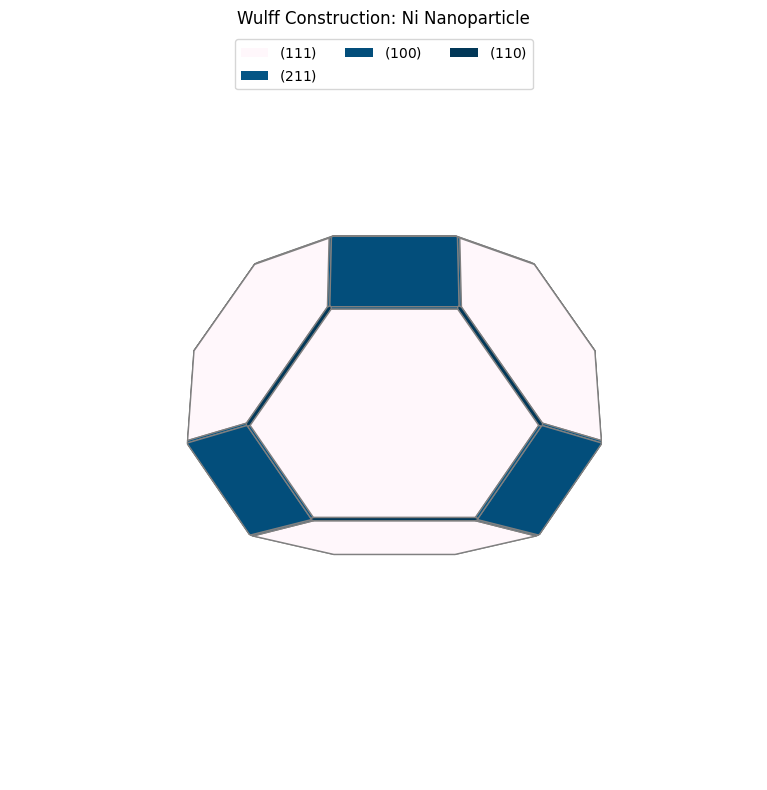


Comparison with paper area fractions:
  (1, 1, 1):   78.1% (Paper: 69.2%)
  (1, 0, 0):   18.3% (Paper: 21.1%)
  (1, 1, 0):    1.9% (Paper: 5.3%)
  (2, 1, 1):    1.7% (Paper: 4.4%)


In [72]:
fig = wulff.get_plot()
plt.title("Wulff Construction: Ni Nanoparticle")
plt.tight_layout()
plt.savefig(str(output_dir / part_dirs["part3"] / "wulff_shape.png"), dpi=200, bbox_inches="tight")
plt.show()

paper_fractions = {
    (1, 1, 1): 69.23,
    (1, 0, 0): 21.10,
    (1, 1, 0): 5.28,
    (2, 1, 1): 4.39,
}

print("\nComparison with paper area fractions:")
for hkl in miller_list:
    calc_frac = area_frac.get(hkl, 0) * 100
    paper_frac = paper_fractions.get(hkl, 0)
    print(f"  {hkl}: {calc_frac:>6.1f}% (Paper: {paper_frac:.1f}%)")


## Physical interpretation

The published calculation produced roughly 78% Ni(111), 18% Ni(100), and only
small Ni(110)/Ni(211) fractions. The paper reported approximately 69.23%,
21.10%, 5.28%, and 4.39%, respectively. Both predict a mostly `{111}` particle
with `{100}` truncations.

This does not mean that minority facets are chemically irrelevant. Edges,
corners, steps, defects, support interactions, strain, adsorbate coverage, and
temperature can change the exposed morphology and can create highly active
minority sites.

## Explore on your own

1. Apply compressive or tensile strain before rebuilding the Wulff shape.
2. Perturb each surface energy by 5–10% to test morphological sensitivity.
3. Explore alloying or segregation through modified facet energies.
4. Model a support interaction by selectively lowering one surface energy.
5. Discuss how edge and corner energies might affect small nanoparticles.


<a name="part-4"></a>
# Part 4: H adsorption energy with ZPE correction

## Introduction and theory

Adsorption energy measures the energetic preference for an adsorbate to bind
to a surface. Using molecular hydrogen as the reference,

$$
E_{\mathrm{ads}} = E(\mathrm{slab+H}) - E(\mathrm{slab})
- \frac{1}{2}E(\mathrm{H_2}).
$$

With this convention, a negative value is exothermic binding. The zero-point
energy correction is

$$
E_{\mathrm{ads}}^{\mathrm{ZPE}} = E_{\mathrm{ads}}
+ \mathrm{ZPE}(\mathrm{H^*}) - \frac{1}{2}\mathrm{ZPE}(\mathrm{H_2}).
$$

The calculation generates several possible adsorption sites, relaxes each,
selects the lowest-energy structure, evaluates the H₂ reference, adds the D3
endpoint correction, and optionally obtains vibrational ZPE values.


## Step 1: Set up the Ni(111) slab and calculators

Generate the Ni(111) slab, use `oc20` for adsorbate–surface energetics, and
initialize the D3 endpoint correction.


In [73]:
# Create Ni(111) slab
ni_bulk_atoms = bulk("Ni", "fcc", a=a_opt, cubic=True)
ni_bulk_obj = Bulk(bulk_atoms=ni_bulk_atoms)
ni_slabs = Slab.from_bulk_get_specific_millers(
    bulk=ni_bulk_obj, specific_millers=(1, 1, 1)
)
ni_slab = ni_slabs[0].atoms

print(f"Created {len(ni_slab)} atom slab")

calc = FAIRChemCalculator(predictor, task_name="oc20")
d3_calc = TorchDFTD3Calculator(device="cpu", damping="bj")
print("Calculators initialized: ML + D3")


Created 96 atom slab
Calculators initialized: ML + D3


## Step 2: Relax the clean slab

Relax the bare surface to obtain the clean-slab reference energy, then evaluate
its D3 endpoint contribution and save the relaxed structure.


In [74]:
print("\n1. Relaxing clean Ni(111) slab...")
clean_slab = ni_slab.copy()
clean_slab.set_pbc([True, True, True])
clean_slab.calc = calc

opt = LBFGS(
    clean_slab,
    trajectory=str(output_dir / part_dirs["part4"] / "ni111_clean.traj"),
    logfile=str(output_dir / part_dirs["part4"] / "ni111_clean.log"),
)
opt.run(fmax=0.05, steps=relaxation_steps)

E_clean_ml = clean_slab.get_potential_energy()
clean_slab.calc = d3_calc
E_clean_d3 = clean_slab.get_potential_energy()
E_clean = E_clean_ml + E_clean_d3

print(f"E(clean): {E_clean:.2f} eV (ML: {E_clean_ml:.2f}, D3: {E_clean_d3:.2f})")
ase.io.write(str(output_dir / part_dirs["part4"] / "ni111_clean.xyz"), clean_slab)


Use inference_settings='batch' for heterogeneous batched evaluations.



1. Relaxing clean Ni(111) slab...


[codecarbon INFO @ 22:55:38] Energy consumed for RAM : 0.000997 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:55:38] Energy consumed for all GPUs : 0.002382 kWh. Total GPU Power : 30.26062187743054 W
[codecarbon INFO @ 22:55:38] Delta energy consumed for CPU with cpu_load : 0.000007 kWh, power : 1.60431575705 W
[codecarbon INFO @ 22:55:38] Energy consumed for All CPU : 0.000305 kWh
[codecarbon INFO @ 22:55:38] 0.003684 kWh of electricity and 0.000000 L of water were used since the beginning.
/usr/local/lib/python3.13/dist-packages/torch_dftd/torch_dftd3_calculator.py:98: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  cell: Optional[Tensor] = torch.tensor(


E(clean): -487.48 eV (ML: -450.70, D3: -36.79)


## Step 3: Generate H adsorption sites

Use the FAIR Chemistry heuristic placement tool to generate candidate top,
bridge, FCC-hollow, and HCP-hollow configurations.


In [75]:
print("\n2. Generating H adsorption sites...")
ni_slab_for_ads = ni_slabs[0]
ni_slab_for_ads.atoms = clean_slab.copy()

adsorbate_h = Adsorbate(adsorbate_smiles_from_db="*H")
ads_slab_config = AdsorbateSlabConfig(
    ni_slab_for_ads,
    adsorbate_h,
    mode="random_site_heuristic_placement",
    num_sites=num_sites,
)

print(f"Generated {len(ads_slab_config.atoms_list)} initial configurations")



2. Generating H adsorption sites...
Generated 5 initial configurations


## Step 4: Relax all H configurations

Relax each candidate, add its D3 endpoint correction, save the structures,
and select the lowest-energy configuration.


In [76]:
print("\n3. Relaxing H adsorption configurations...")

h_energies = []
h_configs = []
h_d3_energies = []

for idx, config in enumerate(ads_slab_config.atoms_list):
    config_relaxed = config.copy()
    config_relaxed.set_pbc([True, True, True])
    config_relaxed.calc = calc

    opt = LBFGS(
        config_relaxed,
        trajectory=str(output_dir / part_dirs["part4"] / f"h_site_{idx+1}.traj"),
        logfile=str(output_dir / part_dirs["part4"] / f"h_site_{idx+1}.log"),
    )
    opt.run(fmax=0.05, steps=relaxation_steps)

    E_ml = config_relaxed.get_potential_energy()
    config_relaxed.calc = d3_calc
    E_d3 = config_relaxed.get_potential_energy()
    E_total = E_ml + E_d3

    h_energies.append(E_total)
    h_configs.append(config_relaxed)
    h_d3_energies.append(E_d3)

    print(f"Config {idx+1}: {E_total:.2f} eV (ML: {E_ml:.2f}, D3: {E_d3:.2f})")
    ase.io.write(str(output_dir / part_dirs["part4"] / f"h_site_{idx+1}.xyz"), config_relaxed)

best_idx = np.argmin(h_energies)
slab_with_h = h_configs[best_idx]
E_with_h = h_energies[best_idx]
E_with_h_d3 = h_d3_energies[best_idx]

print(f"Best site: Config {best_idx + 1}, E = {E_with_h:.2f} eV")
print(f"Energy spread: {max(h_energies) - min(h_energies):.2f} eV")



3. Relaxing H adsorption configurations...
Config 1: -491.55 eV (ML: -454.69, D3: -36.87)


[codecarbon INFO @ 22:56:08] Energy consumed for RAM : 0.001081 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:56:08] Energy consumed for all GPUs : 0.002689 kWh. Total GPU Power : 41.52196848582724 W
[codecarbon INFO @ 22:56:08] Delta energy consumed for CPU with cpu_load : 0.000006 kWh, power : 1.4002332560000001 W
[codecarbon INFO @ 22:56:08] Energy consumed for All CPU : 0.000322 kWh
[codecarbon INFO @ 22:56:08] 0.004091 kWh of electricity and 0.000000 L of water were used since the beginning.


Config 2: -491.55 eV (ML: -454.69, D3: -36.87)
Config 3: -491.54 eV (ML: -454.67, D3: -36.87)


[codecarbon INFO @ 22:56:23] Energy consumed for RAM : 0.001122 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:56:23] Energy consumed for all GPUs : 0.002907 kWh. Total GPU Power : 52.52680367186722 W
[codecarbon INFO @ 22:56:23] Delta energy consumed for CPU with cpu_load : 0.000017 kWh, power : 4.146121673900001 W
[codecarbon INFO @ 22:56:23] Energy consumed for All CPU : 0.000339 kWh
[codecarbon INFO @ 22:56:23] 0.004369 kWh of electricity and 0.000000 L of water were used since the beginning.


Config 4: -491.56 eV (ML: -454.69, D3: -36.87)
Config 5: -491.55 eV (ML: -454.69, D3: -36.87)
Best site: Config 4, E = -491.56 eV
Energy spread: 0.02 eV


## Step 5: Calculate the H₂ reference energy

Relax H₂ in a periodic vacuum box and calculate both the ML and D3 components
of its energy.


In [77]:
print("\n4. Calculating H2 reference energy...")

h2 = Atoms("H2", positions=[[0, 0, 0], [0, 0, 0.74]])
h2.center(vacuum=10.0)
h2.set_pbc([True, True, True])
h2.calc = calc

opt = LBFGS(
    h2,
    trajectory=str(output_dir / part_dirs["part4"] / "h2.traj"),
    logfile=str(output_dir / part_dirs["part4"] / "h2.log"),
)
opt.run(fmax=0.05, steps=relaxation_steps)

E_h2_ml = h2.get_potential_energy()
h2.calc = d3_calc
E_h2_d3 = h2.get_potential_energy()
E_h2 = E_h2_ml + E_h2_d3

print(f"E(H2): {E_h2:.2f} eV (ML: {E_h2_ml:.2f}, D3: {E_h2_d3:.2f})")
ase.io.write(str(output_dir / part_dirs["part4"] / "h2_optimized.xyz"), h2)



4. Calculating H2 reference energy...
E(H2): -6.94 eV (ML: -6.94, D3: -0.00)


## Step 6: Compute the adsorption energy

Combine the adsorbed, clean-slab, and H₂ reference energies and report the D3
contribution explicitly.


In [78]:
print("\n5. Computing adsorption energy:")
print("E_ads = E(slab+H) - E(slab) - 0.5 * E(H2)")

E_ads = E_with_h - E_clean - 0.5 * E_h2
E_ads_no_d3 = (E_with_h - E_with_h_d3) - (E_clean - E_clean_d3) - 0.5 * (E_h2 - E_h2_d3)

print(f"Without D3: {E_ads_no_d3:.2f} eV")
print(f"With D3:    {E_ads:.2f} eV")
print(f"D3 effect:  {E_ads - E_ads_no_d3:.2f} eV")



5. Computing adsorption energy:
E_ads = E(slab+H) - E(slab) - 0.5 * E(H2)
Without D3: -0.52 eV
With D3:    -0.60 eV
D3 effect:  -0.08 eV


## Step 7: Calculate zero-point energy corrections

Calculate the vibrational contributions of adsorbed H and H₂. Inspect the
frequencies and saved mode animation before accepting the correction.



6. Computing ZPE corrections...
ZPE(H*):      0.18+0.00j eV
ZPE(H2):      0.28+0.00j eV
E_ads(ZPE):   -0.56-0.00j eV


[codecarbon INFO @ 22:56:38] Energy consumed for RAM : 0.001164 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:56:38] Energy consumed for all GPUs : 0.003127 kWh. Total GPU Power : 52.507685992425046 W
[codecarbon INFO @ 22:56:38] Delta energy consumed for CPU with cpu_load : 0.000016 kWh, power : 3.7717085680999998 W
[codecarbon INFO @ 22:56:38] Energy consumed for All CPU : 0.000355 kWh
[codecarbon INFO @ 22:56:38] 0.004646 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 22:56:53] Energy consumed for RAM : 0.001205 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:56:53] Energy consumed for all GPUs : 0.003256 kWh. Total GPU Power : 31.30992175058081 W
[codecarbon INFO @ 22:56:53] Delta energy consumed for CPU with cpu_load : 0.000013 kWh, power : 3.2294763142400007 W
[codecarbon INFO @ 22:56:53] Energy consumed for All CPU : 0.000368 kWh
[codecarbon INFO @ 22:56:53] 0.004830 kWh of electricity and 0.000000 L of water were used since the beginn

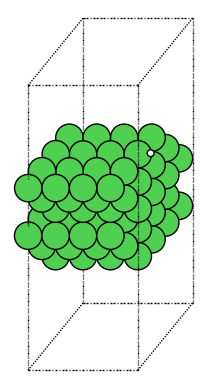

In [79]:
# Optional: zero-point energy correction.
# This can take time because it computes vibrational modes.
RUN_ZPE = True

if RUN_ZPE:
    print("\n6. Computing ZPE corrections...")
    h_index = len(slab_with_h) - 1

    slab_with_h.calc = calc
    vib = Vibrations(slab_with_h, indices=[h_index], delta=0.02)
    vib.run()
    vib_energies = vib.get_energies()
    zpe_ads = np.sum(vib_energies) / 2.0

    h2.calc = calc
    vib_h2 = Vibrations(h2, indices=[0, 1], delta=0.02)
    vib_h2.run()
    vib_energies_h2 = vib_h2.get_energies()
    zpe_h2 = np.sum(vib_energies_h2) / 2.0

    E_ads_zpe = E_ads + zpe_ads - 0.5 * zpe_h2

    print(f"ZPE(H*):      {zpe_ads:.2f} eV")
    print(f"ZPE(H2):      {zpe_h2:.2f} eV")
    print(f"E_ads(ZPE):   {E_ads_zpe:.2f} eV")

    # Preserve the first adsorbate vibrational mode as in the source tutorial.
    vib.write_mode(n=0)
    mode_frames = ase.io.read("vib.0.traj@:")
    ase.io.write(
        str(output_dir / part_dirs["part4"] / "h_vibration_mode_0.gif"),
        mode_frames,
        rotation="-45x,0y,0z",
    )

    vib.clean()
    vib_h2.clean()
else:
    print("Skipping ZPE correction. Set RUN_ZPE = True to run this optional section.")


## Step 8: Visualize and save the best configuration

Inspect the lowest-energy H adsorption geometry and save it for later analysis.


In [80]:
# Visualize the lowest-energy H adsorption configuration

print("Visualizing the best H* configuration...")
view(slab_with_h, viewer="x3d")

# ase.io.write(
#     str(output_dir / part_dirs["part4"] / "h_best.xyz"),
#     slab_with_h,
# )


Visualizing the best H* configuration...


## Interpretation and comparison

The published tutorial found approximately (-0.60\) eV with D3 and about
(-0.56\) eV after ZPE correction. These are reference values, not guaranteed
results: random site generation, model and package versions, convergence, and
geometry can change the result.

D3 is usually modest for a small chemisorbed H atom but can be much more
important for larger molecules and weak adsorption. Inspect vibrational modes;
significant imaginary modes can indicate that a structure is not a stable
minimum or is insufficiently converged.

## Explore on your own

1. Compare top, bridge, FCC-hollow, and HCP-hollow sites explicitly.
2. Increase the number of configurations and test whether the minimum changes.
3. Compare results with and without D3 and ZPE.
4. Tighten the relaxation criterion before calculating frequencies.
5. Replace H with O, N, or another adsorbate and reconsider the reference state.


<a name="part-5"></a>
# Part 5: Coverage-dependent H adsorption

## Introduction and theory

At finite coverage, adsorbate–adsorbate interactions change binding energies.
For (n) H atoms on a slab, the average adsorption energy per H is

$$
E_{\mathrm{ads}}(\theta)=
\frac{E(n\mathrm{H^*})-E(*)-\frac{n}{2}E(\mathrm{H_2})}{n}.
$$

A simple approximation is

$$E_{\mathrm{ads}}(\theta)=E_{\mathrm{ads}}(0)+\beta\theta,$$

where positive (eta) represents increasingly repulsive lateral
interactions. This linear form is an approximation and may fail across
coverage regimes with ordering, reconstruction, or phase changes.


## Step 1: Set up the slab and calculators

Create the Ni(111) slab and initialize the `oc20` and D3 calculators used
throughout the coverage study.


In [81]:
RUN_COVERAGE_STUDY = True

if RUN_COVERAGE_STUDY:
    ni_bulk_atoms = bulk("Ni", "fcc", a=a_opt, cubic=True)
    ni_bulk_obj = Bulk(bulk_atoms=ni_bulk_atoms)
    ni_slabs = Slab.from_bulk_get_specific_millers(
        bulk=ni_bulk_obj, specific_millers=(1, 1, 1)
    )
    slab = ni_slabs[0].atoms.copy()

    print(f"Created {len(slab)} atom slab")

    base_calc = FAIRChemCalculator(predictor, task_name="oc20")
    d3_calc = TorchDFTD3Calculator(device="cpu", damping="bj")
else:
    print("Coverage study skipped. Set RUN_COVERAGE_STUDY = True to run it.")


Created 96 atom slab


## Step 2: Calculate reference energies

Relax the clean surface and H₂ reference using the same conventions that will
be applied to every coverage configuration.


In [82]:
if RUN_COVERAGE_STUDY:
    print("\n1. Relaxing clean slab...")
    clean_slab_cov = slab.copy()
    clean_slab_cov.pbc = True
    clean_slab_cov.calc = base_calc

    opt = LBFGS(
        clean_slab_cov,
        trajectory=str(output_dir / part_dirs["part5"] / "ni111_clean.traj"),
        logfile=str(output_dir / part_dirs["part5"] / "ni111_clean.log"),
    )
    opt.run(fmax=0.05, steps=relaxation_steps)

    E_clean_ml = clean_slab_cov.get_potential_energy()
    clean_slab_cov.calc = d3_calc
    E_clean_d3 = clean_slab_cov.get_potential_energy()
    E_clean_cov = E_clean_ml + E_clean_d3

    print(f"E(clean): {E_clean_cov:.2f} eV")

    print("\n2. Calculating H2 reference...")
    h2_cov = Atoms("H2", positions=[[0, 0, 0], [0, 0, 0.74]])
    h2_cov.center(vacuum=10.0)
    h2_cov.set_pbc([True, True, True])
    h2_cov.calc = base_calc

    opt = LBFGS(
        h2_cov,
        trajectory=str(output_dir / part_dirs["part5"] / "h2.traj"),
        logfile=str(output_dir / part_dirs["part5"] / "h2.log"),
    )
    opt.run(fmax=0.05, steps=relaxation_steps)

    E_h2_ml = h2_cov.get_potential_energy()
    h2_cov.calc = d3_calc
    E_h2_d3 = h2_cov.get_potential_energy()
    E_h2_cov = E_h2_ml + E_h2_d3

    print(f"E(H2): {E_h2_cov:.2f} eV")



1. Relaxing clean slab...


[codecarbon INFO @ 22:57:08] Energy consumed for RAM : 0.001247 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:57:08] Energy consumed for all GPUs : 0.003395 kWh. Total GPU Power : 33.53828749268995 W
[codecarbon INFO @ 22:57:08] Delta energy consumed for CPU with cpu_load : 0.000012 kWh, power : 3.0020009781500008 W
[codecarbon INFO @ 22:57:08] Energy consumed for All CPU : 0.000381 kWh
[codecarbon INFO @ 22:57:08] 0.005022 kWh of electricity and 0.000000 L of water were used since the beginning.


E(clean): -487.48 eV

2. Calculating H2 reference...
E(H2): -6.94 eV


## Step 3: Define the coverage study

Count the surface sites, define the number of H atoms to test, and initialize
the arrays used to store coverage and adsorption energy.


In [83]:
if RUN_COVERAGE_STUDY:
    tags = slab.get_tags()
    n_sites = np.sum(tags == 1)
    print(f"Surface sites: {n_sites}")

    coverages_to_test = [1, 4, 8] if FAST_MODE else [1, 4, 8, 12, 16]
    print(f"Will test coverages: {[f'{n/n_sites:.2f} ML' for n in coverages_to_test]}")

    coverages = []
    adsorption_energies = []


Surface sites: 16
Will test coverages: ['0.06 ML', '0.25 ML', '0.50 ML', '0.75 ML', '1.00 ML']


## Step 4: Generate and relax configurations at each coverage

Generate several arrangements for each coverage, relax them, select and save
the lowest-energy relaxed structure, and calculate adsorption energy per H.


In [84]:
if RUN_COVERAGE_STUDY:
    for n_h in coverages_to_test:
        print(f"\nCoverage: {n_h} H ({n_h/n_sites:.2f} ML)")

        ni_bulk_obj_h = Bulk(bulk_atoms=ni_bulk_atoms)
        ni_slabs_h = Slab.from_bulk_get_specific_millers(
            bulk=ni_bulk_obj_h, specific_millers=(1, 1, 1)
        )
        slab_for_ads = ni_slabs_h[0]
        slab_for_ads.atoms = clean_slab_cov.copy()

        adsorbates_list = [Adsorbate(adsorbate_smiles_from_db="*H") for _ in range(n_h)]

        try:
            multi_ads_config = MultipleAdsorbateSlabConfig(
                slab_for_ads, adsorbates_list, num_configurations=num_sites
            )
        except ValueError as e:
            print(f"Configuration generation failed: {e}")
            continue

        if len(multi_ads_config.atoms_list) == 0:
            print("No configurations generated.")
            continue

        print(f"Generated {len(multi_ads_config.atoms_list)} configurations")
        config_energies = []
        relaxed_configs = []

        for idx, config in enumerate(multi_ads_config.atoms_list):
            config_relaxed = config.copy()
            config_relaxed.set_pbc([True, True, True])
            config_relaxed.calc = base_calc

            opt = LBFGS(config_relaxed, logfile=None)
            opt.run(fmax=0.05, steps=relaxation_steps)

            E_ml = config_relaxed.get_potential_energy()
            config_relaxed.calc = d3_calc
            E_d3 = config_relaxed.get_potential_energy()
            E_total = E_ml + E_d3

            config_energies.append(E_total)
            relaxed_configs.append(config_relaxed.copy())
            print(f"  Config {idx+1}: {E_total:.2f} eV")

        best_idx = int(np.argmin(config_energies))
        best_energy = config_energies[best_idx]
        best_config = relaxed_configs[best_idx]
        ase.io.write(
            str(output_dir / part_dirs["part5"] / f"coverage_{n_h:02d}H_best.xyz"),
            best_config,
        )
        E_ads_per_h = (best_energy - E_clean_cov - n_h * 0.5 * E_h2_cov) / n_h

        coverage = n_h / n_sites
        coverages.append(coverage)
        adsorption_energies.append(E_ads_per_h)

        print(f"E_ads/H: {E_ads_per_h:.2f} eV")



Coverage: 1 H (0.06 ML)
Generated 5 configurations


[codecarbon INFO @ 22:57:23] Energy consumed for RAM : 0.001288 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:57:23] Energy consumed for all GPUs : 0.003664 kWh. Total GPU Power : 64.66031693619507 W
[codecarbon INFO @ 22:57:23] Delta energy consumed for CPU with cpu_load : 0.000012 kWh, power : 2.83210576865 W
[codecarbon INFO @ 22:57:23] Energy consumed for All CPU : 0.000392 kWh
[codecarbon INFO @ 22:57:23] 0.005345 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 22:57:23] 0.007197 g.CO2eq/s mean an estimation of 226.9509221616144 kg.CO2eq/year
[codecarbon INFO @ 22:57:38] Energy consumed for RAM : 0.001330 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:57:38] Energy consumed for all GPUs : 0.003936 kWh. Total GPU Power : 65.09308018747397 W
[codecarbon INFO @ 22:57:38] Delta energy consumed for CPU with cpu_load : 0.000014 kWh, power : 3.2731503515000004 W
[codecarbon INFO @ 22:57:38] Energy consumed for All CPU : 0.000406 kWh
[codecarbon

  Config 1: -490.97 eV
  Config 2: -491.56 eV


[codecarbon INFO @ 22:58:08] Energy consumed for RAM : 0.001413 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:58:08] Energy consumed for all GPUs : 0.004443 kWh. Total GPU Power : 56.52106483079373 W
[codecarbon INFO @ 22:58:08] Delta energy consumed for CPU with cpu_load : 0.000014 kWh, power : 3.4110330987500004 W
[codecarbon INFO @ 22:58:08] Energy consumed for All CPU : 0.000436 kWh
[codecarbon INFO @ 22:58:08] 0.006292 kWh of electricity and 0.000000 L of water were used since the beginning.


  Config 3: -491.54 eV
  Config 4: -491.56 eV


...

  Config 3: -549.20 eV


[codecarbon INFO @ 23:04:08] Energy consumed for RAM : 0.002412 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:04:08] Energy consumed for all GPUs : 0.010557 kWh. Total GPU Power : 60.39788412761741 W
[codecarbon INFO @ 23:04:08] Delta energy consumed for CPU with cpu_load : 0.000012 kWh, power : 2.76045058475 W
[codecarbon INFO @ 23:04:08] Energy consumed for All CPU : 0.000742 kWh
[codecarbon INFO @ 23:04:08] 0.013711 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:04:23] Energy consumed for RAM : 0.002454 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:04:23] Energy consumed for all GPUs : 0.010831 kWh. Total GPU Power : 65.94107435312479 W
[codecarbon INFO @ 23:04:23] Delta energy consumed for CPU with cpu_load : 0.000011 kWh, power : 2.7241457246000005 W
[codecarbon INFO @ 23:04:23] Energy consumed for All CPU : 0.000753 kWh
[codecarbon INFO @ 23:04:23] 0.014039 kWh of electricity and 0.000000 L of water were used since the beginning.


  Config 4: -550.81 eV


[codecarbon INFO @ 23:04:38] Energy consumed for RAM : 0.002496 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:04:38] Energy consumed for all GPUs : 0.011083 kWh. Total GPU Power : 60.50517473215477 W
[codecarbon INFO @ 23:04:38] Delta energy consumed for CPU with cpu_load : 0.000012 kWh, power : 2.7768515309 W
[codecarbon INFO @ 23:04:38] Energy consumed for All CPU : 0.000765 kWh
[codecarbon INFO @ 23:04:38] 0.014344 kWh of electricity and 0.000000 L of water were used since the beginning.


  Config 5: -549.75 eV
E_ads/H: -0.49 eV


## Step 5: Perform the linear fit

Fit adsorption energy against coverage and extract the lateral-interaction
parameter, (\beta).


In [85]:
if 'coverages' in globals() and len(coverages) >= 2:
    coverages_arr = np.array(coverages)
    energies_arr = np.array(adsorption_energies)

    coeffs = np.polyfit(coverages_arr, energies_arr, 1)
    beta = coeffs[0]
    intercept = coeffs[1]

    print("Coverage-dependent adsorption fit:")
    print(f"  E_ads(theta) = {intercept:.3f} + {beta:.3f} * theta")
    print(f"  beta = {beta:.3f} eV/ML = {beta * 96.485:.1f} kJ/mol/ML")
else:
    print("Not enough coverage points to fit.")


Coverage-dependent adsorption fit:
  E_ads(theta) = -0.623 + 0.121 * theta
  beta = 0.121 eV/ML = 11.6 kJ/mol/ML


## Step 6: Visualize coverage dependence

Plot the calculated coverage points and the fitted linear approximation.


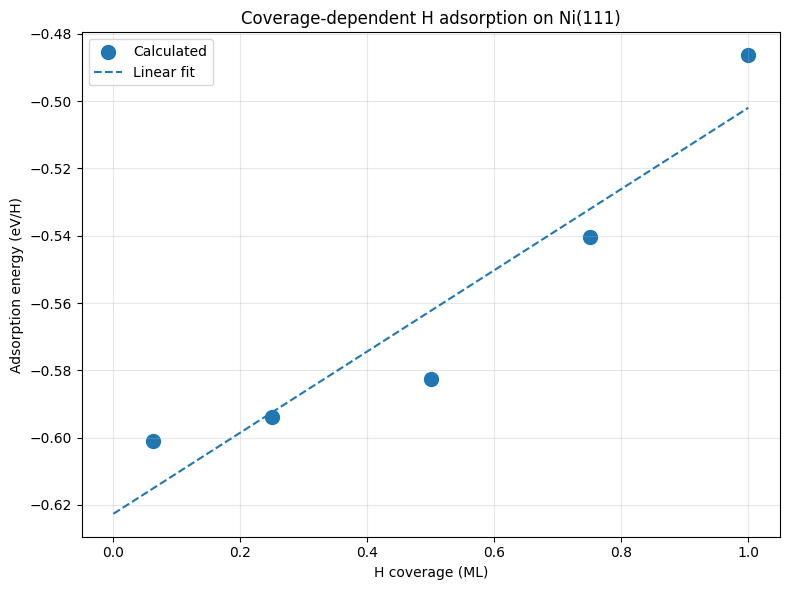

In [86]:
if 'coverages' in globals() and len(coverages) >= 2:
    x_fit = np.linspace(0, max(coverages_arr), 100)
    y_fit = intercept + beta * x_fit

    plt.figure(figsize=(8, 6))
    plt.scatter(coverages_arr, energies_arr, s=100, label="Calculated")
    plt.plot(x_fit, y_fit, "--", label="Linear fit")
    plt.xlabel("H coverage (ML)")
    plt.ylabel("Adsorption energy (eV/H)")
    plt.title("Coverage-dependent H adsorption on Ni(111)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(str(output_dir / part_dirs["part5"] / "coverage_dependence.png"), dpi=200)
    plt.show()
else:
    print("Not enough coverage points to plot.")


## Interpretation and comparison

The original tutorial observed binding that became progressively weaker near
high coverage and compared the fitted slope with the paper value of about
8.7 kJ/mol per monolayer. Treat the fit cautiously: the low- and high-coverage
regions may not belong to one linear regime, and using only two points in fast
mode is not a meaningful convergence study.

The generated arrangements should be inspected because the lowest calculated
energy can depend on adsorbate ordering and on whether the geometry actually
relaxed to the intended coverage state.

## Explore on your own

1. Fit low- and high-coverage regions separately.
2. Compare linear and quadratic models without overinterpreting sparse data.
3. Increase the number of configurations at each coverage.
4. Inspect whether adsorbates cluster, order, desorb, or reconstruct the surface.
5. Test a different adsorbate and discuss the implications for microkinetics.


<a name="part-6"></a>
# Part 6: CO formation/dissociation thermochemistry and barrier

## Introduction and theory

CO dissociation is important in processes such as Fischer–Tropsch chemistry.
The tutorial evaluates recombination in the forward direction,

$$\mathrm{C^*+O^*\rightarrow CO^*+*},$$

and dissociation in the reverse direction. For a specified direction,

$$\Delta E_{\mathrm{rxn}}=E_{\mathrm{final}}-E_{\mathrm{initial}},$$

and the activation energy is

$$E_a=E^\ddagger-E_{\mathrm{initial}}.$$

NEB represents the path with a chain of images connected by springs. The
climbing-image variant pushes the highest-energy image toward the saddle point.
The endpoint geometries and atom ordering must be compatible, and the entire
path must be inspected to confirm that it is chemically meaningful.


## Step 1: Set up the slab and calculators

Initialize the Ni(111) surface, the `oc20` UMA calculator, and the D3 endpoint
calculator used in the thermochemistry calculations.


In [87]:
# Part 6 setup: slab and calculators

from ase.constraints import FixBondLengths
from ase.mep import interpolate
from ase.mep.dyneb import DyNEB
from ase.io import write as ase_write

ni_bulk_atoms = bulk("Ni", "fcc", a=a_opt, cubic=True)
ni_bulk_obj = Bulk(bulk_atoms=ni_bulk_atoms)
ni_slabs = Slab.from_bulk_get_specific_millers(
    bulk=ni_bulk_obj, specific_millers=(1, 1, 1)
)
slab = ni_slabs[0].atoms

print(f"Created {len(slab)} atom slab")

base_calc = FAIRChemCalculator(predictor, task_name="oc20")
d3_calc = TorchDFTD3Calculator(device="cpu", damping="bj")
print("Calculators initialized")


Created 96 atom slab
Calculators initialized


## Step 2: Generate and relax final state (`CO*`)

Find the most stable CO adsorption configuration. This is the product of C + O recombination.


In [88]:
print("\n1. Final State: CO* on Ni(111)")
print("   Generating CO adsorption configurations...")

ni_bulk_obj_co = Bulk(bulk_atoms=ni_bulk_atoms)
ni_slab_co = Slab.from_bulk_get_specific_millers(
    bulk=ni_bulk_obj_co, specific_millers=(1, 1, 1)
)[0]
ni_slab_co.atoms = slab.copy()

adsorbate_co = Adsorbate(adsorbate_smiles_from_db="*CO")
multi_ads_config_co = MultipleAdsorbateSlabConfig(
    ni_slab_co, [adsorbate_co], num_configurations=num_sites
)

print(f"Generated {len(multi_ads_config_co.atoms_list)} configurations")

co_energies = []
co_energies_ml = []
co_energies_d3 = []
co_configs = []

for idx, config in enumerate(multi_ads_config_co.atoms_list):
    config_relaxed = config.copy()
    config_relaxed.set_pbc([True, True, True])
    config_relaxed.calc = base_calc
    opt = LBFGS(config_relaxed, logfile=None)
    opt.run(fmax=0.05, steps=relaxation_steps)

    E_ml = config_relaxed.get_potential_energy()
    config_relaxed.calc = d3_calc
    E_d3 = config_relaxed.get_potential_energy()
    E_total = E_ml + E_d3

    co_energies.append(E_total)
    co_energies_ml.append(E_ml)
    co_energies_d3.append(E_d3)
    co_configs.append(config_relaxed)
    print(f"Config {idx+1}: E_total = {E_total:.2f} eV (RPBE: {E_ml:.2f}, D3: {E_d3:.2f})")

best_co_idx = np.argmin(co_energies)
final_co = co_configs[best_co_idx]
E_final_co = co_energies[best_co_idx]
E_final_co_ml = co_energies_ml[best_co_idx]
E_final_co_d3 = co_energies_d3[best_co_idx]

print(f"\n→ Best CO* (Config {best_co_idx+1}):")
print(f"   RPBE:  {E_final_co_ml:.2f} eV")
print(f"   D3:    {E_final_co_d3:.2f} eV")
print(f"   Total: {E_final_co:.2f} eV")

ase.io.write(str(output_dir / part_dirs["part6"] / "co_final_best.traj"), final_co)
print("Best CO* structure saved")
view(final_co, viewer="x3d")



1. Final State: CO* on Ni(111)
   Generating CO adsorption configurations...
Generated 5 configurations
Config 1: E_total = -503.61 eV (RPBE: -466.55, D3: -37.06)


[codecarbon INFO @ 23:04:53] Energy consumed for RAM : 0.002537 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:04:53] Energy consumed for all GPUs : 0.011298 kWh. Total GPU Power : 51.57038257215921 W
[codecarbon INFO @ 23:04:53] Delta energy consumed for CPU with cpu_load : 0.000013 kWh, power : 3.1159142193500005 W
[codecarbon INFO @ 23:04:53] Energy consumed for All CPU : 0.000778 kWh
[codecarbon INFO @ 23:04:53] 0.014613 kWh of electricity and 0.000000 L of water were used since the beginning.


Config 2: E_total = -503.98 eV (RPBE: -466.94, D3: -37.04)
Config 3: E_total = -503.98 eV (RPBE: -466.94, D3: -37.04)


[codecarbon INFO @ 23:05:08] Energy consumed for RAM : 0.002579 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:05:08] Energy consumed for all GPUs : 0.011534 kWh. Total GPU Power : 56.672368095327016 W
[codecarbon INFO @ 23:05:08] Delta energy consumed for CPU with cpu_load : 0.000017 kWh, power : 4.0102450262 W
[codecarbon INFO @ 23:05:08] Energy consumed for All CPU : 0.000795 kWh
[codecarbon INFO @ 23:05:08] 0.014907 kWh of electricity and 0.000000 L of water were used since the beginning.


Config 4: E_total = -503.98 eV (RPBE: -466.94, D3: -37.04)
Config 5: E_total = -503.62 eV (RPBE: -466.55, D3: -37.07)

→ Best CO* (Config 2):
   RPBE:  -466.94 eV
   D3:    -37.04 eV
   Total: -503.98 eV
Best CO* structure saved


## Step 3: Generate and relax initial state (`C* + O*`)

Find the most stable configuration for dissociated carbon and oxygen adsorbates. Configurations where C and O recombine into a CO molecule are rejected.


In [89]:
print("\n2. Initial State: C* + O* on Ni(111)")
print("   Generating C+O configurations...")

ni_bulk_obj_c_o = Bulk(bulk_atoms=ni_bulk_atoms)
ni_slab_c_o = Slab.from_bulk_get_specific_millers(
    bulk=ni_bulk_obj_c_o, specific_millers=(1, 1, 1)
)[0]
ni_slab_c_o.atoms = slab.copy()

adsorbate_c = Adsorbate(adsorbate_smiles_from_db="*C")
adsorbate_o = Adsorbate(adsorbate_smiles_from_db="*O")

multi_ads_config_c_o = MultipleAdsorbateSlabConfig(
    ni_slab_c_o, [adsorbate_c, adsorbate_o], num_configurations=num_sites
)

print(f"Generated {len(multi_ads_config_c_o.atoms_list)} configurations")

c_o_energies = []
c_o_energies_ml = []
c_o_energies_d3 = []
c_o_configs = []

for idx, config in enumerate(multi_ads_config_c_o.atoms_list):
    config_relaxed = config.copy()
    config_relaxed.set_pbc([True, True, True])
    config_relaxed.calc = base_calc
    opt = LBFGS(config_relaxed, logfile=None)
    opt.run(fmax=0.05, steps=relaxation_steps)

    ads_indices = np.where(config_relaxed.get_tags() == 2)[0]
    if len(ads_indices) >= 2:
        c_o_dist = config_relaxed.get_distance(ads_indices[0], ads_indices[1], mic=True)
    else:
        c_o_dist = np.nan

    if len(ads_indices) >= 2 and c_o_dist < 1.5:
        print(f"Config {idx+1}: REJECTED - C and O formed CO molecule (d = {c_o_dist:.2f} Å)")
        continue

    E_ml = config_relaxed.get_potential_energy()
    config_relaxed.calc = d3_calc
    E_d3 = config_relaxed.get_potential_energy()
    E_total = E_ml + E_d3

    c_o_energies.append(E_total)
    c_o_energies_ml.append(E_ml)
    c_o_energies_d3.append(E_d3)
    c_o_configs.append(config_relaxed)
    print(f"Config {idx+1}: E_total = {E_total:.2f} eV (RPBE: {E_ml:.2f}, D3: {E_d3:.2f}, C-O dist: {c_o_dist:.2f} Å)")

if not c_o_energies:
    raise RuntimeError("No valid C* + O* configurations remained after rejecting recombined CO structures.")

best_c_o_idx = np.argmin(c_o_energies)
initial_c_o = c_o_configs[best_c_o_idx]
E_initial_c_o = c_o_energies[best_c_o_idx]
E_initial_c_o_ml = c_o_energies_ml[best_c_o_idx]
E_initial_c_o_d3 = c_o_energies_d3[best_c_o_idx]

print(f"\n→ Best C*+O* (Config {best_c_o_idx+1}):")
print(f"   RPBE:  {E_initial_c_o_ml:.2f} eV")
print(f"   D3:    {E_initial_c_o_d3:.2f} eV")
print(f"   Total: {E_initial_c_o:.2f} eV")

ase.io.write(str(output_dir / part_dirs["part6"] / "co_initial_best.traj"), initial_c_o)
print("Best C*+O* structure saved")
view(initial_c_o, viewer="x3d")



2. Initial State: C* + O* on Ni(111)
   Generating C+O configurations...
Generated 5 configurations


[codecarbon INFO @ 23:05:23] Energy consumed for RAM : 0.002620 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:05:23] Energy consumed for all GPUs : 0.011767 kWh. Total GPU Power : 55.92988873472764 W
[codecarbon INFO @ 23:05:23] Delta energy consumed for CPU with cpu_load : 0.000012 kWh, power : 2.9825768748500003 W
[codecarbon INFO @ 23:05:23] Energy consumed for All CPU : 0.000807 kWh
[codecarbon INFO @ 23:05:23] 0.015194 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:05:23] 0.009448 g.CO2eq/s mean an estimation of 297.95359742704426 kg.CO2eq/year


Config 1: E_total = -502.73 eV (RPBE: -465.63, D3: -37.10, C-O dist: 3.83 Å)
Config 2: REJECTED - C and O formed CO molecule (d = 1.17 Å)


[codecarbon INFO @ 23:05:38] Energy consumed for RAM : 0.002662 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:05:38] Energy consumed for all GPUs : 0.012025 kWh. Total GPU Power : 61.97935129121473 W
[codecarbon INFO @ 23:05:38] Delta energy consumed for CPU with cpu_load : 0.000013 kWh, power : 3.1785268332500003 W
[codecarbon INFO @ 23:05:38] Energy consumed for All CPU : 0.000820 kWh
[codecarbon INFO @ 23:05:38] 0.015507 kWh of electricity and 0.000000 L of water were used since the beginning.


Config 3: REJECTED - C and O formed CO molecule (d = 1.20 Å)
Config 4: E_total = -502.75 eV (RPBE: -465.64, D3: -37.10, C-O dist: 5.72 Å)


[codecarbon INFO @ 23:05:53] Energy consumed for RAM : 0.002704 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:05:53] Energy consumed for all GPUs : 0.012282 kWh. Total GPU Power : 61.888422236062944 W
[codecarbon INFO @ 23:05:53] Delta energy consumed for CPU with cpu_load : 0.000013 kWh, power : 3.1496477372 W
[codecarbon INFO @ 23:05:53] Energy consumed for All CPU : 0.000833 kWh
[codecarbon INFO @ 23:05:53] 0.015819 kWh of electricity and 0.000000 L of water were used since the beginning.


Config 5: E_total = -502.56 eV (RPBE: -465.47, D3: -37.09, C-O dist: 3.30 Å)

→ Best C*+O* (Config 2):
   RPBE:  -465.64 eV
   D3:    -37.10 eV
   Total: -502.75 eV
Best C*+O* structure saved


## Step 3b: Calculate `C*` and `O*` energies separately

The original tutorial also calculates `C*` and `O*` in separate unit cells as a low-coverage reference, which avoids direct interactions between the two reactants.


In [90]:
# Clean slab
ni_bulk_obj_clean = Bulk(bulk_atoms=ni_bulk_atoms)
clean_slab = Slab.from_bulk_get_specific_millers(
    bulk=ni_bulk_obj_clean, specific_millers=(1, 1, 1)
)[0].atoms
clean_slab.set_pbc([True, True, True])
clean_slab.calc = base_calc
opt = LBFGS(clean_slab, logfile=None)
opt.run(fmax=0.05, steps=relaxation_steps)

E_clean_ml = clean_slab.get_potential_energy()
clean_slab.calc = d3_calc
E_clean_d3 = clean_slab.get_potential_energy()
E_clean = E_clean_ml + E_clean_d3

print(f"\nClean slab: E_total = {E_clean:.2f} eV (RPBE: {E_clean_ml:.2f}, D3: {E_clean_d3:.2f})")

print("\n2b. Separate C* and O* Energies:")
print("    Calculating energies in separate unit cells to avoid interactions")

ni_bulk_obj_c_o = Bulk(bulk_atoms=ni_bulk_atoms)
ni_slab_c_o = Slab.from_bulk_get_specific_millers(
    bulk=ni_bulk_obj_c_o, specific_millers=(1, 1, 1)
)[0]
ni_slab_c_o.atoms = slab.copy()

print("\nGenerating C* configurations...")
multi_ads_config_c = MultipleAdsorbateSlabConfig(
    ni_slab_c_o,
    adsorbates=[Adsorbate(adsorbate_smiles_from_db="*C")],
    num_configurations=num_sites,
)

c_energies = []
c_energies_ml = []
c_energies_d3 = []
c_configs = []

for idx, config in enumerate(multi_ads_config_c.atoms_list):
    config_relaxed = config.copy()
    config_relaxed.set_pbc([True, True, True])
    config_relaxed.calc = base_calc
    opt = LBFGS(config_relaxed, logfile=None)
    opt.run(fmax=0.05, steps=relaxation_steps)

    E_ml = config_relaxed.get_potential_energy()
    config_relaxed.calc = d3_calc
    E_d3 = config_relaxed.get_potential_energy()
    E_total = E_ml + E_d3

    c_energies.append(E_total)
    c_energies_ml.append(E_ml)
    c_energies_d3.append(E_d3)
    c_configs.append(config_relaxed)
    print(f"Config {idx+1}: E_total = {E_total:.2f} eV (RPBE: {E_ml:.2f}, D3: {E_d3:.2f})")

best_c_idx = np.argmin(c_energies)
c_ads = c_configs[best_c_idx]
E_c = c_energies[best_c_idx]
E_c_ml = c_energies_ml[best_c_idx]
E_c_d3 = c_energies_d3[best_c_idx]

print(f"\n→ Best C* (Config {best_c_idx+1}):")
print(f"   RPBE:  {E_c_ml:.2f} eV")
print(f"   D3:    {E_c_d3:.2f} eV")
print(f"   Total: {E_c:.2f} eV")
ase.io.write(str(output_dir / part_dirs["part6"] / "c_best.traj"), c_ads)
view(c_ads, viewer="x3d")

print("\nGenerating O* configurations...")
multi_ads_config_o = MultipleAdsorbateSlabConfig(
    ni_slab_c_o,
    adsorbates=[Adsorbate(adsorbate_smiles_from_db="*O")],
    num_configurations=num_sites,
)

o_energies = []
o_energies_ml = []
o_energies_d3 = []
o_configs = []

for idx, config in enumerate(multi_ads_config_o.atoms_list):
    config_relaxed = config.copy()
    config_relaxed.set_pbc([True, True, True])
    config_relaxed.calc = base_calc
    opt = LBFGS(config_relaxed, logfile=None)
    opt.run(fmax=0.05, steps=relaxation_steps)

    E_ml = config_relaxed.get_potential_energy()
    config_relaxed.calc = d3_calc
    E_d3 = config_relaxed.get_potential_energy()
    E_total = E_ml + E_d3

    o_energies.append(E_total)
    o_energies_ml.append(E_ml)
    o_energies_d3.append(E_d3)
    o_configs.append(config_relaxed)
    print(f"Config {idx+1}: E_total = {E_total:.2f} eV (RPBE: {E_ml:.2f}, D3: {E_d3:.2f})")

best_o_idx = np.argmin(o_energies)
o_ads = o_configs[best_o_idx]
E_o = o_energies[best_o_idx]
E_o_ml = o_energies_ml[best_o_idx]
E_o_d3 = o_energies_d3[best_o_idx]

print(f"\n→ Best O* (Config {best_o_idx+1}):")
print(f"   RPBE:  {E_o_ml:.2f} eV")
print(f"   D3:    {E_o_d3:.2f} eV")
print(f"   Total: {E_o:.2f} eV")
ase.io.write(str(output_dir / part_dirs["part6"] / "o_best.traj"), o_ads)
view(o_ads, viewer="x3d")

E_initial_c_o_separate = E_c + E_o
E_initial_c_o_separate_ml = E_c_ml + E_o_ml
E_initial_c_o_separate_d3 = E_c_d3 + E_o_d3

print("\nCombined C* + O* (separate calculations):")
print(f"   RPBE:  {E_initial_c_o_separate_ml:.2f} eV")
print(f"   D3:    {E_initial_c_o_separate_d3:.2f} eV")
print(f"   Total: {E_initial_c_o_separate:.2f} eV")

print("\nComparison:")
print(f"   C*+O* (same cell):  {E_initial_c_o - E_clean:.2f} eV")
print(f"   C* + O* (separate): {E_initial_c_o_separate - 2 * E_clean:.2f} eV")
print(f"   Difference:         {(E_initial_c_o - E_clean) - (E_initial_c_o_separate - 2 * E_clean):.2f} eV")
print("Separate C* and O* energies calculated")



Clean slab: E_total = -487.48 eV (RPBE: -450.70, D3: -36.79)

2b. Separate C* and O* Energies:
    Calculating energies in separate unit cells to avoid interactions

Generating C* configurations...


[codecarbon INFO @ 23:06:08] Energy consumed for RAM : 0.002745 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:06:08] Energy consumed for all GPUs : 0.012515 kWh. Total GPU Power : 55.78218940756778 W
[codecarbon INFO @ 23:06:08] Delta energy consumed for CPU with cpu_load : 0.000013 kWh, power : 3.22210693925 W
[codecarbon INFO @ 23:06:08] Energy consumed for All CPU : 0.000847 kWh
[codecarbon INFO @ 23:06:08] 0.016107 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:06:23] Energy consumed for RAM : 0.002787 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:06:23] Energy consumed for all GPUs : 0.012786 kWh. Total GPU Power : 65.27549371999294 W
[codecarbon INFO @ 23:06:23] Delta energy consumed for CPU with cpu_load : 0.000014 kWh, power : 3.2697680110400005 W
[codecarbon INFO @ 23:06:23] Energy consumed for All CPU : 0.000860 kWh
[codecarbon INFO @ 23:06:23] 0.016434 kWh of electricity and 0.000000 L of water were used since the beginning.


Config 1: E_total = -495.68 eV (RPBE: -458.70, D3: -36.99)


[codecarbon INFO @ 23:06:38] Energy consumed for RAM : 0.002829 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:06:38] Energy consumed for all GPUs : 0.013031 kWh. Total GPU Power : 58.88794266663618 W
[codecarbon INFO @ 23:06:38] Delta energy consumed for CPU with cpu_load : 0.000013 kWh, power : 3.2190155963000002 W
[codecarbon INFO @ 23:06:38] Energy consumed for All CPU : 0.000874 kWh
[codecarbon INFO @ 23:06:38] 0.016734 kWh of electricity and 0.000000 L of water were used since the beginning.


Config 2: E_total = -495.68 eV (RPBE: -458.69, D3: -36.99)
Config 3: E_total = -495.74 eV (RPBE: -458.74, D3: -37.00)
Config 4: E_total = -495.69 eV (RPBE: -458.70, D3: -36.99)


...

Config 2: E_total = -494.68 eV (RPBE: -457.78, D3: -36.90)
Config 3: E_total = -494.58 eV (RPBE: -457.68, D3: -36.89)


[codecarbon INFO @ 23:07:23] Energy consumed for RAM : 0.002953 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:07:23] Energy consumed for all GPUs : 0.013757 kWh. Total GPU Power : 57.499424194327695 W
[codecarbon INFO @ 23:07:23] Delta energy consumed for CPU with cpu_load : 0.000012 kWh, power : 2.77907336675 W
[codecarbon INFO @ 23:07:23] Energy consumed for All CPU : 0.000909 kWh
[codecarbon INFO @ 23:07:23] 0.017620 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:07:23] 0.009516 g.CO2eq/s mean an estimation of 300.0849021668131 kg.CO2eq/year
[codecarbon INFO @ 23:07:38] Energy consumed for RAM : 0.002995 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:07:38] Energy consumed for all GPUs : 0.014028 kWh. Total GPU Power : 65.11089550205135 W
[codecarbon INFO @ 23:07:38] Delta energy consumed for CPU with cpu_load : 0.000012 kWh, power : 2.8798214282 W
[codecarbon INFO @ 23:07:38] Energy consumed for All CPU : 0.000921 kWh
[codecarbon INFO

Config 4: E_total = -494.68 eV (RPBE: -457.79, D3: -36.90)


[codecarbon INFO @ 23:07:53] Energy consumed for RAM : 0.003037 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:07:53] Energy consumed for all GPUs : 0.014283 kWh. Total GPU Power : 61.38429250858122 W
[codecarbon INFO @ 23:07:53] Delta energy consumed for CPU with cpu_load : 0.000017 kWh, power : 3.983802969500001 W
[codecarbon INFO @ 23:07:53] Energy consumed for All CPU : 0.000938 kWh
[codecarbon INFO @ 23:07:53] 0.018258 kWh of electricity and 0.000000 L of water were used since the beginning.


Config 5: E_total = -494.57 eV (RPBE: -457.68, D3: -36.89)

→ Best O* (Config 1):
   RPBE:  -457.78 eV
   D3:    -36.90 eV
   Total: -494.68 eV

Combined C* + O* (separate calculations):
   RPBE:  -916.53 eV
   D3:    -73.90 eV
   Total: -990.43 eV

Comparison:
   C*+O* (same cell):  -15.26 eV
   C* + O* (separate): -15.46 eV
   Difference:         0.20 eV
Separate C* and O* energies calculated


## Step 4: Calculate reaction energy with ZPE

Compute the thermochemistry for `C* + O* → CO*`, including RPBE, D3, and zero-point energy terms.


In [91]:
print("\n3. Reaction Energy (C* + O* → CO*):")
print("=" * 60)

print("\nElectronic Energies:")
print(f"Initial (C*+O*): RPBE = {E_initial_c_o_ml:.2f} eV, D3 = {E_initial_c_o_d3:.2f} eV, Total = {E_initial_c_o:.2f} eV")
print(f"Final (CO*):     RPBE = {E_final_co_ml:.2f} eV, D3 = {E_final_co_d3:.2f} eV, Total = {E_final_co:.2f} eV")

# Reaction energies without ZPE
delta_E_rpbe = E_final_co_ml - E_initial_c_o_ml
delta_E_d3_contrib = E_final_co_d3 - E_initial_c_o_d3
delta_E_elec = E_final_co - E_initial_c_o

print("\nReaction Energies (without ZPE):")
print(f"ΔE(RPBE only):  {delta_E_rpbe:.2f} eV = {delta_E_rpbe * 96.485:.1f} kJ/mol")
print(f"ΔE(D3 contrib): {delta_E_d3_contrib:.2f} eV = {delta_E_d3_contrib * 96.485:.1f} kJ/mol")
print(f"ΔE(RPBE+D3):    {delta_E_elec:.2f} eV = {delta_E_elec * 96.485:.1f} kJ/mol")

# Calculate ZPE for CO* (final state)
print("\nComputing ZPE for CO*...")
final_co.calc = base_calc
co_indices = np.where(final_co.get_tags() == 2)[0]
vib_co = Vibrations(final_co, indices=co_indices, delta=0.02, name="vib_co")
vib_co.run()
vib_energies_co = vib_co.get_energies()
zpe_co = np.sum(vib_energies_co[vib_energies_co > 0]) / 2.0
vib_co.clean()
print(f"ZPE(CO*): {zpe_co:.2f} eV ({zpe_co * 1000:.1f} meV)")

# Calculate ZPE for C* and O* (initial state)
print("\nComputing ZPE for C* and O*...")
initial_c_o.calc = base_calc
c_o_indices = np.where(initial_c_o.get_tags() == 2)[0]
vib_c_o = Vibrations(initial_c_o, indices=c_o_indices, delta=0.02, name="vib_c_o")
vib_c_o.run()
vib_energies_c_o = vib_c_o.get_energies()
zpe_c_o = np.sum(vib_energies_c_o[vib_energies_c_o > 0]) / 2.0
vib_c_o.clean()
print(f"ZPE(C*+O*): {zpe_c_o:.2f} eV ({zpe_c_o * 1000:.1f} meV)")

# Total reaction energy with ZPE
delta_zpe = zpe_co - zpe_c_o
delta_E_zpe = delta_E_elec + delta_zpe

print("\nReaction Energy (with ZPE):")
print(f"ΔE(electronic): {delta_E_elec:.2f} eV = {delta_E_elec * 96.485:.1f} kJ/mol")
print(f"ΔZPE:           {delta_zpe:.2f} eV = {delta_zpe * 96.485:.1f} kJ/mol ({delta_zpe * 1000:.1f} meV)")
print(f"ΔE(total):      {delta_E_zpe:.2f} eV = {delta_E_zpe * 96.485:.1f} kJ/mol")

print("\nSummary:")
print(f"Without D3, without ZPE: {delta_E_rpbe:.2f} eV = {delta_E_rpbe * 96.485:.1f} kJ/mol")
print(f"With D3, without ZPE:    {delta_E_elec:.2f} eV = {delta_E_elec * 96.485:.1f} kJ/mol")
print(f"With D3, with ZPE:       {delta_E_zpe:.2f} eV = {delta_E_zpe * 96.485:.1f} kJ/mol")

print("\n" + "=" * 60)
print("\nComparison with Paper (Table 5):")
print("Paper (DFT-D3): -142.7 kJ/mol = -1.48 eV")
print(f"This work:      {delta_E_zpe * 96.485:.1f} kJ/mol = {delta_E_zpe:.2f} eV")
print(f"Difference:     {abs(delta_E_zpe - (-1.48)):.2f} eV")

if delta_E_zpe < 0:
    print("\nReaction is exothermic (C+O recombination favorable)")
else:
    print("\nReaction is endothermic (dissociation favorable)")



3. Reaction Energy (C* + O* → CO*):

Electronic Energies:
Initial (C*+O*): RPBE = -465.64 eV, D3 = -37.10 eV, Total = -502.75 eV
Final (CO*):     RPBE = -466.94 eV, D3 = -37.04 eV, Total = -503.98 eV

Reaction Energies (without ZPE):
ΔE(RPBE only):  -1.30 eV = -125.4 kJ/mol
ΔE(D3 contrib): 0.06 eV = 5.9 kJ/mol
ΔE(RPBE+D3):    -1.24 eV = -119.5 kJ/mol

Computing ZPE for CO*...
ZPE(CO*): 0.18+0.00j eV (182.1+0.0j meV)

Computing ZPE for C* and O*...
ZPE(C*+O*): 0.18+0.00j eV (175.4+0.0j meV)

Reaction Energy (with ZPE):
ΔE(electronic): -1.24 eV = -119.5 kJ/mol
ΔZPE:           0.01+0.00j eV = 0.6+0.0j kJ/mol (6.6+0.0j meV)
ΔE(total):      -1.23+0.00j eV = -118.8+0.0j kJ/mol

Summary:
Without D3, without ZPE: -1.30 eV = -125.4 kJ/mol
With D3, without ZPE:    -1.24 eV = -119.5 kJ/mol
With D3, with ZPE:       -1.23+0.00j eV = -118.8+0.0j kJ/mol


Comparison with Paper (Table 5):
Paper (DFT-D3): -142.7 kJ/mol = -1.48 eV
This work:      -118.8+0.0j kJ/mol = -1.23+0.00j eV
Difference:     0.25

## Step 5: Calculate CO adsorption energy

Calculate how strongly CO binds to the Ni(111) surface and compare with paper values.


In [92]:
print("\n4. CO Adsorption Energy (CO(g) + * → CO*):")
print("   This helps us understand CO binding strength")

# CO(g)
co_gas = Atoms("CO", positions=[[0, 0, 0], [0, 0, 1.15]])
co_gas.center(vacuum=10.0)
co_gas.set_pbc([True, True, True])
co_gas.calc = base_calc
opt = LBFGS(co_gas, logfile=None)
opt.run(fmax=0.05, steps=relaxation_steps)

E_co_gas_ml = co_gas.get_potential_energy()
co_gas.calc = d3_calc
E_co_gas_d3 = co_gas.get_potential_energy()
E_co_gas = E_co_gas_ml + E_co_gas_d3

print(f"CO(g): E_total = {E_co_gas:.2f} eV (RPBE: {E_co_gas_ml:.2f}, D3: {E_co_gas_d3:.2f})")

# Calculate ZPE for CO(g)
co_gas.calc = base_calc
vib_co_gas = Vibrations(co_gas, indices=[0, 1], delta=0.01, nfree=2)
vib_co_gas.clean()
vib_co_gas.run()
vib_energies_co_gas = vib_co_gas.get_energies()
zpe_co_gas = 0.5 * np.sum(vib_energies_co_gas[vib_energies_co_gas > 0])
vib_co_gas.clean()

print(f"ZPE(CO(g)): {zpe_co_gas:.2f} eV")
print(f"ZPE(CO*):   {zpe_co:.2f} eV (from Step 3 calculation)")

E_ads_co_elec = E_final_co - E_clean - E_co_gas
delta_zpe_ads = zpe_co - zpe_co_gas
E_ads_co_total = E_ads_co_elec + delta_zpe_ads

print("\nElectronic Energy Breakdown:")
print(f"ΔE(RPBE only)  = {(E_final_co_ml - E_clean_ml - E_co_gas_ml):.2f} eV")
print(f"ΔE(D3 contrib) = {(E_final_co_d3 - E_clean_d3 - E_co_gas_d3):.2f} eV")
print(f"ΔE(RPBE+D3)    = {E_ads_co_elec:.2f} eV")

print("\nZPE Contribution:")
print(f"ΔZPE = {delta_zpe_ads:.2f} eV")

print("\nTotal Adsorption Energy:")
print(f"ΔE(total) = {E_ads_co_total:.2f} eV = {E_ads_co_total * 96.485:.1f} kJ/mol")

print("\nSummary:")
print(f"E_ads(CO) without ZPE = {-E_ads_co_elec:.2f} eV = {-E_ads_co_elec * 96.485:.1f} kJ/mol")
print(f"E_ads(CO) with ZPE    = {-E_ads_co_total:.2f} eV = {-E_ads_co_total * 96.485:.1f} kJ/mol")
print(f"CO binds {abs(E_ads_co_total):.2f} eV stronger than H ({abs(E_ads_co_total) / 0.60:.1f}x)")



4. CO Adsorption Energy (CO(g) + * → CO*):
   This helps us understand CO binding strength
CO(g): E_total = -14.51 eV (RPBE: -14.50, D3: -0.01)
ZPE(CO(g)): 0.13+0.00j eV
ZPE(CO*):   0.18+0.00j eV (from Step 3 calculation)

Electronic Energy Breakdown:
ΔE(RPBE only)  = -1.75 eV
ΔE(D3 contrib) = -0.24 eV
ΔE(RPBE+D3)    = -1.99 eV

ZPE Contribution:
ΔZPE = 0.05-0.00j eV

Total Adsorption Energy:
ΔE(total) = -1.94-0.00j eV = -187.4-0.0j kJ/mol

Summary:
E_ads(CO) without ZPE = 1.99 eV = 192.3 kJ/mol
E_ads(CO) with ZPE    = 1.94+0.00j eV = 187.4+0.0j kJ/mol
CO binds 1.94 eV stronger than H (3.2x)


### Comparison with paper results

The paper reports a CO adsorption energy of **1.82 eV** (**175.6 kJ/mol**) in Table 4, calculated using DFT with the RPBE functional.

These results usually show:

- Without ZPE, the electronic binding energy should match reasonably well with DFT predictions.
- With ZPE, the zero-point energy correction reduces the binding strength slightly.
- D3 dispersion contributes to stronger binding due to van der Waals interactions.


## Step 6: Find guesses for nearby initial and final states for the reaction

The original tutorial starts from the relaxed `CO*` final state, stretches the C–O bond, and relaxes the structure first with a fixed C–O distance and then without the constraint. This creates a nearby local minimum for the `C* + O*` side of the reaction before running NEB.


In [93]:
print("\nFinding transition-state initial and final states")
print("Creating initial guess with stretched C-O bond...")
print("Starting from CO* and stretching the C-O bond...")

initial_guess = final_co.copy()
initial_slab = initial_guess[initial_guess.get_tags() != 2]
initial_co = initial_guess[initial_guess.get_tags() == 2]
initial_co.rotate(30, "x", center=initial_co.positions[0])
initial_guess = initial_slab + initial_co
initial_guess.set_pbc([True, True, True])
initial_guess.calc = FAIRChemCalculator(predictor, task_name="oc20")

co_indices_guess = np.where(initial_guess.get_tags() == 2)[0]
if len(co_indices_guess) < 2:
    raise RuntimeError("Could not identify the C/O adsorbate atoms for the stretched CO initial guess.")

constraint = FixBondLengths([co_indices_guess[:2]], tolerance=1e-2, iterations=5000, bondlengths=[2.0])
initial_guess.set_constraint(constraint)

try:
    opt = LBFGS(
        initial_guess,
        trajectory=str(output_dir / part_dirs["part6"] / "initial_guess_with_constraint.traj"),
    )
    opt.run(fmax=0.01)
except RuntimeError:
    print("Constraint relaxation stopped early; continuing with unconstrained relaxation.")

initial_guess.set_constraint()
opt = LBFGS(
    initial_guess,
    trajectory=str(output_dir / part_dirs["part6"] / "initial_guess_without_constraint.traj"),
)
opt.run(fmax=0.01)
print("Initial guess relaxed without constraint.")



Finding transition-state initial and final states
Creating initial guess with stretched C-O bond...
Starting from CO* and stretching the C-O bond...
       Step     Time          Energy          fmax
LBFGS:    0 23:08:03     -466.614100        0.945066
LBFGS:    1 23:08:03     -461.286143        4.632770
LBFGS:    2 23:08:03     -461.362534        4.158579
LBFGS:    3 23:08:03     -461.743112        1.072269
LBFGS:    4 23:08:03     -461.817067        1.097922
LBFGS:    5 23:08:04     -461.855771        1.022445
LBFGS:    6 23:08:04     -461.851742        0.693765
LBFGS:    7 23:08:04     -461.931122        0.788670
LBFGS:    8 23:08:04     -461.947344        0.888156
LBFGS:    9 23:08:04     -461.976532        0.659877
LBFGS:   10 23:08:04     -462.051372        0.612047
LBFGS:   11 23:08:05     -462.117415        0.772102
LBFGS:   12 23:08:05     -462.283648        1.189320
LBFGS:   13 23:08:05     -462.398078        1.794456
LBFGS:   14 23:08:05     -462.412474        1.922253
LBFG

[codecarbon INFO @ 23:08:08] Energy consumed for RAM : 0.003078 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:08:08] Energy consumed for all GPUs : 0.014535 kWh. Total GPU Power : 60.53929701665967 W
[codecarbon INFO @ 23:08:08] Delta energy consumed for CPU with cpu_load : 0.000013 kWh, power : 3.2032249491500004 W
[codecarbon INFO @ 23:08:08] Energy consumed for All CPU : 0.000951 kWh
[codecarbon INFO @ 23:08:08] 0.018565 kWh of electricity and 0.000000 L of water were used since the beginning.


LBFGS:   31 23:08:08     -463.203785        0.258558
LBFGS:   32 23:08:08     -463.214060        0.277793
LBFGS:   33 23:08:08     -463.217401        0.264337
LBFGS:   34 23:08:08     -463.224033        0.259551
LBFGS:   35 23:08:09     -463.245674        0.201739
LBFGS:   36 23:08:09     -463.239932        0.219694
LBFGS:   37 23:08:09     -463.260774        0.324451
LBFGS:   38 23:08:09     -463.259647        0.224847
LBFGS:   39 23:08:09     -463.265994        0.238894
LBFGS:   40 23:08:09     -463.272352        0.227355
Constraint relaxation stopped early; continuing with unconstrained relaxation.
       Step     Time          Energy          fmax
LBFGS:    0 23:08:10     -463.279224        1.504478
LBFGS:    1 23:08:10     -463.336008        1.638502
LBFGS:    2 23:08:10     -463.093134        2.111691
LBFGS:    3 23:08:10     -463.642845        2.895918
LBFGS:    4 23:08:10     -463.102926        1.947188
LBFGS:    5 23:08:10     -462.467910        9.366799
LBFGS:    6 23:08:10  

[codecarbon INFO @ 23:08:23] Energy consumed for RAM : 0.003120 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:08:23] Energy consumed for all GPUs : 0.014809 kWh. Total GPU Power : 65.66501942642877 W
[codecarbon INFO @ 23:08:23] Delta energy consumed for CPU with cpu_load : 0.000011 kWh, power : 2.7535034780000003 W
[codecarbon INFO @ 23:08:23] Energy consumed for All CPU : 0.000963 kWh
[codecarbon INFO @ 23:08:23] 0.018891 kWh of electricity and 0.000000 L of water were used since the beginning.


LBFGS:   83 23:08:23     -466.877289        1.185176
LBFGS:   84 23:08:23     -466.892621        0.967023
LBFGS:   85 23:08:23     -466.905324        1.134388
LBFGS:   86 23:08:23     -466.918403        0.798500
LBFGS:   87 23:08:23     -466.935662        0.635612
LBFGS:   88 23:08:24     -466.953310        0.490776
LBFGS:   89 23:08:24     -466.966754        0.519371
LBFGS:   90 23:08:24     -466.978260        0.669751
LBFGS:   91 23:08:24     -466.990629        0.836304
LBFGS:   92 23:08:24     -467.006755        0.897444
LBFGS:   93 23:08:24     -467.023042        0.725606
LBFGS:   94 23:08:25     -467.034038        0.527829
LBFGS:   95 23:08:25     -467.042684        0.379246
LBFGS:   96 23:08:25     -467.052303        0.478351
LBFGS:   97 23:08:25     -467.062285        0.567513
LBFGS:   98 23:08:25     -467.070746        0.535317
LBFGS:   99 23:08:25     -467.076739        0.351151
LBFGS:  100 23:08:25     -467.081433        0.286817
LBFGS:  101 23:08:26     -467.085934        0.

## Step 7: Run NEB to find activation barrier

Use the nudged elastic band method to estimate the minimum energy path between `C* + O*` and `CO*`. The original tutorial uses a 10-intermediate-image NEB chain, with the climbing-image DyNEB variant.


In [94]:
print("\n7. NEB Barrier Calculation (C* + O* → CO*)")
print("   Setting up NEB chain with TS guess in the middle...")
print("   Reaction: C* + O* (initial) → TS → CO* (final)")

initial = initial_guess.copy()
initial.calc = FAIRChemCalculator(predictor, task_name="oc20")
images = [initial]

# n_images is configured above: 10 for the full tutorial, fewer in FAST_MODE.
for i in range(n_images):
    image = initial.copy()
    image.calc = FAIRChemCalculator(predictor, task_name="oc20")
    images.append(image)

final = final_co.copy()
final.calc = FAIRChemCalculator(predictor, task_name="oc20")
images.append(final)

dyneb = DyNEB(images, climb=True, fmax=0.05)

print("\nInterpolating images...")
dyneb.interpolate("idpp", mic=True)

print("Optimizing NEB path. This may take a while...")
opt = FIRE(
    dyneb,
    trajectory=str(output_dir / part_dirs["part6"] / "neb.traj"),
    logfile=str(output_dir / part_dirs["part6"] / "neb.log"),
)
opt.run(fmax=0.1, steps=neb_steps)

energies = [img.get_potential_energy() for img in images]
energies_rel = np.array(energies) - energies[0]
E_barrier = np.max(energies_rel)
reverse_barrier = E_barrier - energies_rel[-1]

print("\nNEB converged or stopped at the requested step limit.")
print(f"Forward barrier (C*+O* → CO*): {E_barrier:.2f} eV = {E_barrier * 96.485:.1f} kJ/mol")
print(f"Reverse barrier (CO* → C*+O*): {reverse_barrier:.2f} eV = {reverse_barrier * 96.485:.1f} kJ/mol")
print("\nPaper (Table 5): 153 kJ/mol = 1.59 eV")
print(f"Difference in reverse/dissociation barrier: {abs(reverse_barrier - 1.59):.2f} eV")



7. NEB Barrier Calculation (C* + O* → CO*)
   Setting up NEB chain with TS guess in the middle...
   Reaction: C* + O* (initial) → TS → CO* (final)

Interpolating images...


/usr/local/lib/python3.13/dist-packages/ase/mep/neb.py:329: UserWarning: The default method has changed from 'aseneb' to 'improvedtangent'. The 'aseneb' method is an unpublished, custom implementation that is not recommended as it frequently results in very poor bands. Please explicitly set method='improvedtangent' to silence this warning, or set method='aseneb' if you strictly require the old behavior (results may vary). See: https://gitlab.com/ase/ase/-/merge_requests/3952
  warnings.warn(


Optimizing NEB path. This may take a while...


[codecarbon INFO @ 23:08:38] Energy consumed for RAM : 0.003162 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:08:38] Energy consumed for all GPUs : 0.015073 kWh. Total GPU Power : 63.54404380779122 W
[codecarbon INFO @ 23:08:38] Delta energy consumed for CPU with cpu_load : 0.000012 kWh, power : 2.8249968990500003 W
[codecarbon INFO @ 23:08:38] Energy consumed for All CPU : 0.000974 kWh
[codecarbon INFO @ 23:08:38] 0.019209 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:08:53] Energy consumed for RAM : 0.003203 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:08:53] Energy consumed for all GPUs : 0.015343 kWh. Total GPU Power : 64.76350848643001 W
[codecarbon INFO @ 23:08:53] Delta energy consumed for CPU with cpu_load : 0.000011 kWh, power : 2.75378170895 W
[codecarbon INFO @ 23:08:53] Energy consumed for All CPU : 0.000986 kWh
[codecarbon INFO @ 23:08:53] 0.019532 kWh of electricity and 0.000000 L of water were used since the beginning.
[


NEB converged or stopped at the requested step limit.
Forward barrier (C*+O* → CO*): 0.17 eV = 16.8 kJ/mol
Reverse barrier (CO* → C*+O*): 0.00 eV = 0.0 kJ/mol

Paper (Table 5): 153 kJ/mol = 1.59 eV
Difference in reverse/dissociation barrier: 1.59 eV


## Step 8: Visualize NEB path and key structures

Create plots showing the reaction pathway, save a GIF of the NEB path, and visualize the initial, transition-state, and final structures.



Creating NEB visualization...


/usr/local/lib/python3.13/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


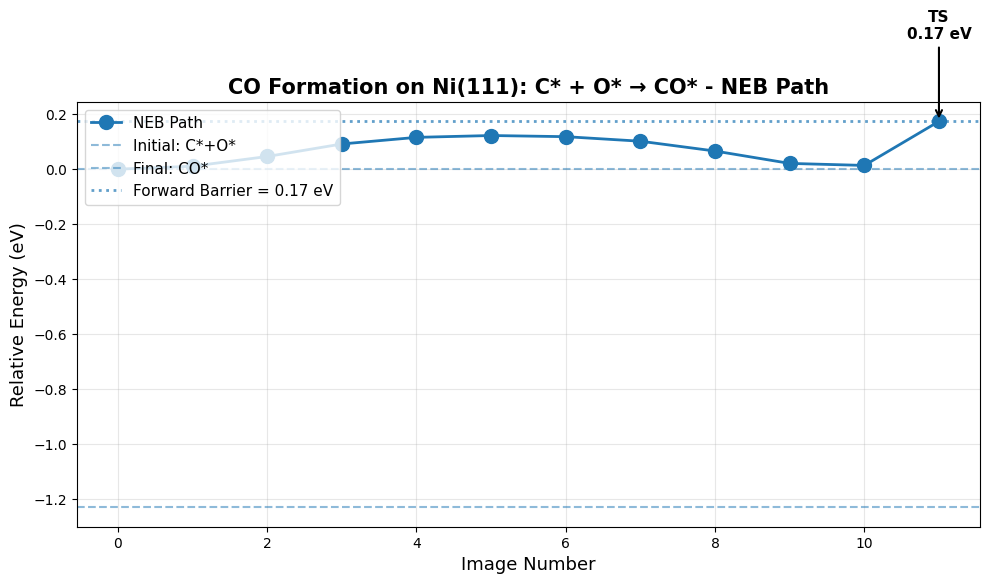


Creating NEB path animation...


[codecarbon INFO @ 23:09:23] Energy consumed for RAM : 0.003286 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:09:23] Energy consumed for all GPUs : 0.015836 kWh. Total GPU Power : 53.39115984653625 W
[codecarbon INFO @ 23:09:23] Delta energy consumed for CPU with cpu_load : 0.000016 kWh, power : 3.7888047917 W
[codecarbon INFO @ 23:09:23] Energy consumed for All CPU : 0.001015 kWh
[codecarbon INFO @ 23:09:23] 0.020138 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 23:09:23] 0.009871 g.CO2eq/s mean an estimation of 311.29101007261715 kg.CO2eq/year


Saved as neb_path.gif

Visualizing initial state (C* + O*)...

Visualizing transition state...

Visualizing final state (CO*)...

NEB analysis complete


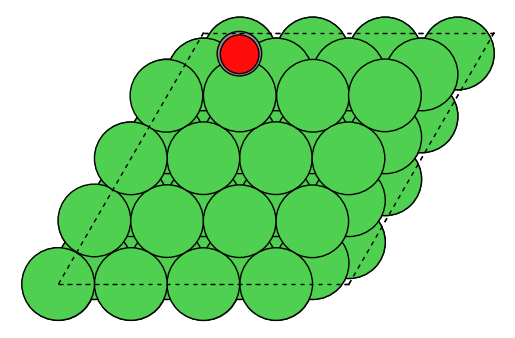

In [95]:
print("\nCreating NEB visualization...")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(len(energies_rel)), energies_rel, "o-", linewidth=2, markersize=10, label="NEB Path")
ax.axhline(0, linestyle="--", alpha=0.5, label="Initial: C*+O*")
ax.axhline(delta_E_zpe, linestyle="--", alpha=0.5, label="Final: CO*")
ax.axhline(E_barrier, linestyle=":", alpha=0.7, linewidth=2, label=f"Forward Barrier = {E_barrier:.2f} eV")

ts_idx = int(np.argmax(energies_rel))
ax.annotate(
    f"TS\n{energies_rel[ts_idx]:.2f} eV",
    xy=(ts_idx, energies_rel[ts_idx]),
    xytext=(ts_idx, energies_rel[ts_idx] + 0.3),
    ha="center",
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", lw=1.5),
)

ax.set_xlabel("Image Number", fontsize=13)
ax.set_ylabel("Relative Energy (eV)", fontsize=13)
ax.set_title("CO Formation on Ni(111): C* + O* → CO* - NEB Path", fontsize=15, fontweight="bold")
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(output_dir / part_dirs["part6"] / "neb_path.png"), dpi=300, bbox_inches="tight")
plt.show()

print("\nCreating NEB path animation...")
ase.io.write(str(output_dir / part_dirs["part6"] / "neb_path.gif"), images, format="gif")
print("Saved as neb_path.gif")

print("\nVisualizing initial state (C* + O*)...")
view(initial_c_o, viewer="x3d")

print("\nVisualizing transition state...")
view(images[ts_idx], viewer="x3d")

print("\nVisualizing final state (CO*)...")
view(final_co, viewer="x3d")

print("\nNEB analysis complete")


### Comparison with paper: Tables 4 and 5

Expected results from the paper:

- **Reaction energy (`C* + O* → CO*`)**: about **-142.7 kJ/mol = -1.48 eV**. This is exothermic with DFT-D3.
- **Activation barrier (`CO* → C* + O*`)**: about **153 kJ/mol = 1.59 eV** for the reverse/dissociation direction.
- **CO adsorption energy**: about **1.82 eV = 175.6 kJ/mol** with DFT-D3.

Reaction direction:

- The paper reports the CO dissociation barrier, `CO* → C* + O*`, which is the reverse of the recombination direction calculated in the forward NEB path.
- Forward recombination, `C* + O* → CO*`, should have a much smaller barrier because the reaction is strongly exothermic.
- Reverse CO dissociation should have a substantial barrier and is the kinetic bottleneck.

What to check:

- Reaction energy should be strongly exothermic, roughly `-1.5 eV`.
- Reverse barrier should be substantial, roughly `1.6 eV`.
- Forward recombination barrier should be small, roughly `0.1 eV`.
- CO should bind much more strongly than H.

Typical variations:

- Reaction energies are often accurate within about `0.1–0.2 eV`.
- Barriers are more sensitive, with possible variation around `±0.2–0.3 eV`.
- ZPE corrections often add around `0.05–0.15 eV`.
- NEB convergence affects the barrier more than the reaction energy.

Physical insight:

- A large reverse barrier makes CO dissociation slow at low temperature.
- A small forward barrier means C and O can rapidly recombine to CO.
- This helps explain why Ni can produce CO in Fischer-Tropsch-like chemistry instead of keeping C and O separated.
- Higher temperatures may be needed to overcome the dissociation barrier for further C-C coupling.

### NEB method explained

The nudged elastic band method finds the minimum energy path between reactants and products:

1. Interpolate between initial and final states.
2. Add spring forces along the chain to maintain spacing.
3. Project spring-force components to follow the path.
4. Use the climbing-image variant to push the highest-energy image toward the saddle point.

Advantages:

- It does not require exact prior knowledge of the transition state.
- It provides a full reaction coordinate.
- It is useful for complex reactions.

Limitations:

- It is computationally expensive because several images are optimized.
- It may find the wrong path if the initial interpolation is poor.

### Explore on your own

1. Run with 7 or 9 images and compare the barrier.
2. Modify the NEB spring constant and check convergence.
3. Try different initial `CO*` and final `C* + O*` configurations.
4. Calculate the reverse barrier and compare with Brønsted-Evans-Polanyi relationships.
5. Compute C or O diffusion barriers on the surface and compare them with the reaction barrier.


<a name="summary"></a>
# Summary and best practices

## Key takeaways

- UMA can greatly accelerate screening, but quantitative claims require validation.
- Use the ML-relaxed lattice constant consistently throughout the workflow.
- Use multiple slab thicknesses and inspect linearity for surface energies.
- Test several adsorption sites and configurations; surface chemistry is non-convex.
- Coverage effects can become important well below one monolayer.
- NEB is sensitive to endpoints, geometry, image count, and convergence.

## Recommended workflow for a new catalyst

1. Optimize the bulk structure.
2. Calculate and converge surface energies.
3. Construct the Wulff morphology.
4. Identify low-coverage adsorption sites and energies.
5. Evaluate coverage dependence where relevant.
6. Calculate important reaction and diffusion barriers.
7. Validate selected quantities with DFT.
8. Use validated energetics in microkinetic modelling.
9. Compare model predictions with experiment.

## Approximate accuracy expectations from the source tutorial

| Property | Typical error | Especially important for |
|---|---:|---|
| Lattice constants | 1–2% | strain and alloy studies |
| Surface energies | 10–20% | nanoparticle morphology |
| Adsorption energies | 0.1–0.3 eV | thermochemistry and selectivity |
| Reaction barriers | 0.2–0.5 eV | kinetics and rate prediction |

These ranges are heuristics, not guarantees.

> **Rule of thumb:** ML for screening → DFT for validation → experiment for verification.


<a name="troubleshooting"></a>
# Appendix: Troubleshooting

## Convergence failures

- Start with a looser force threshold such as `fmax=0.1`, then tighten it.
- Inspect the trajectory for atoms entering vacuum or overlapping.
- Try a different starting configuration; the current geometry may be metastable.
- Confirm that the calculator and task name match the chemistry.

## NEB fails or produces an unreasonable transition state

- Improve the endpoint structures and ensure identical atom ordering.
- Increase the number of images, commonly to 7–11.
- Use IDPP interpolation and inspect every image before optimization.
- Start with coarse convergence and refine afterward.
- Try a different starting path or spring constant.
- Confirm that the maximum image represents the intended chemistry.

## Unexpected adsorption energies

- Visualize every relaxed structure.
- Check reference-state signs and stoichiometry.
- Test more sites and orientations.
- Compare with and without D3.
- Check whether the adsorbate desorbed, fragmented, or reconstructed the surface.

## Out of memory or excessive runtime

- Use `FAST_MODE=True` only for a demonstration.
- Reduce the supercell or NEB image count for debugging.
- Run expensive full settings on suitable GPU/HPC infrastructure.
- Cache and reuse converged reference structures and energies.

## Hugging Face/model-loading failures

- Confirm that model access was approved.
- Confirm that the token can read gated repositories.
- Restart the runtime after installation if imports remain stale.


<a name="caveats"></a>
# Caveats and pitfalls

## 1. Task selection: `omat` versus `oc20`

Use `omat` for bulk structures and clean-surface calculations. Use `oc20` for
adsorbate–surface chemistry. The source tutorial warns that the wrong task can
shift adsorption energies by roughly 0.1–0.3 eV.

## 2. D3 dispersion corrections

D3 is often small for H, O, or N chemisorption but can be important for CO,
CO₂, aromatics, and physisorption. This tutorial adds D3 as an endpoint energy
correction after ML relaxation. Including dispersion during optimization can
change geometries but is more expensive. Functional parameterization matters:
PBE-D3 and RPBE-D3 are not interchangeable, and adding D3 to RPBE can sometimes
increase overbinding.

## 3. Coverage dependence

The linear model can fail near ordering transitions, reconstruction, or high
coverage. Do not fit across distinct regimes without testing the assumption.
At very low coverage, changes may be smaller than numerical/model noise.

## 4. Periodic boundary conditions

UMA calculations here use periodic boundaries in all directions, including
gas molecules placed in a large vacuum box. Missing PBC can cause failures or
inconsistent energies.

## 5. Gas-phase reference energies

Prefer stable molecular references such as H₂ rather than isolated H. CO and
O₂ references should be checked carefully, and radicals are generally more
difficult. Reference choice directly affects adsorption thermochemistry.

## 6. Spin polarization

The OC20/UMA workflow does not explicitly reproduce a spin-polarized DFT
calculation. This can matter for magnetic metals such as Fe, Co, and Ni,
open-shell adsorbates, and radical-containing reaction paths.

## 7. Constraint philosophy

Symmetric clean slabs may be relaxed without constraints for surface-energy
work. Adsorbate slabs commonly fix lower layers to represent the bulk and
reduce unwanted reconstruction. Inspect the constraints applied by helper
functions instead of assuming they are appropriate for every system.

## 8. Real catalyst complexity

Low-index ideal surfaces omit steps, kinks, vacancies, grain boundaries,
support interfaces, strain, alloy segregation, and finite-temperature
reconstruction. These features may dominate real catalytic activity.

## 9. Slab thickness and vacuum

The 4–8-layer slabs and 10 Å vacuum are tutorial choices, not universal
convergence guarantees. Test both quantities for a new material, especially
for weak screening, charged systems, or major reconstruction.

## 10. NEB convergence

NEB is generally the most expensive and fragile calculation in the notebook.
The path may require 7–11 or more images, several searches from different
endpoints, alternative spring constants, and tighter final convergence.

## 11. Lattice-constant consistency

Use one defensible lattice-constant source consistently. Do not silently mix
ML-relaxed geometries with unrelated bulk or surface reference energies.

## 12. Adsorbate placement and local minima

Five generated configurations are only a small sample. Complex adsorbates may
require 10–20 orientations or global-search methods such as minima hopping,
basin hopping, or genetic algorithms.


<a name="codecarbon-stop"></a>
# Computational-emissions estimate

The following cell stops the single tracker surrounding the scientific
workflow. The result is an approximate operational-emissions estimate. It is
reported in kg CO₂eq and grams CO₂eq and saved with detailed measurements in
the tutorial results directory.


In [96]:
# Stop computational-emissions tracking

if "tracker" in globals() and tracker is not None:
    emissions_kg = tracker.stop()
    tracker = None

    if emissions_kg is not None:
        emissions_g = emissions_kg * 1000
        print("=" * 65)
        print("CODECARBON COMPUTATIONAL-EMISSIONS ESTIMATE")
        print("=" * 65)
        print(f"Estimated emissions: {emissions_kg:.8f} kg CO₂eq")
        print(f"Estimated emissions: {emissions_g:.5f} g CO₂eq")
        print(f"Detailed results: {output_dir / 'emissions.csv'}")
        print("=" * 65)
    else:
        print("Tracking stopped, but no emissions estimate was returned.")
else:
    print("No active CodeCarbon tracker was found.")


[codecarbon INFO @ 23:09:28] Energy consumed for RAM : 0.003300 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 23:09:28] Energy consumed for all GPUs : 0.015882 kWh. Total GPU Power : 34.17518123891572 W
[codecarbon INFO @ 23:09:28] Delta energy consumed for CPU with cpu_load : 0.000003 kWh, power : 2.0227712924000003 W
[codecarbon INFO @ 23:09:28] Energy consumed for All CPU : 0.001018 kWh
[codecarbon INFO @ 23:09:28] 0.020201 kWh of electricity and 0.000000 L of water were used since the beginning.


CODECARBON COMPUTATIONAL-EMISSIONS ESTIMATE
Estimated emissions: 0.00951020 kg CO₂eq
Estimated emissions: 9.51020 g CO₂eq
Detailed results: ccai_uma_catalysis_results/emissions.csv


<a name="responsible-use"></a>
# Model card and responsible use

**Model:** UMA-S-1P2 universal machine-learning potential.

**Use in this notebook:** Educational screening-style calculations for
catalyst surfaces, adsorption, and reaction paths.

**Appropriate uses:** Rapid hypothesis generation, comparative screening,
initial geometry relaxation, and prioritization of higher-fidelity work.

**Do not use alone for:** final industrial catalyst selection, safety-critical
decisions, regulatory claims, or publication-quality quantitative conclusions.

Important limitations include training-data coverage, out-of-distribution
structures, missing physics such as explicit spin treatment, idealized surface
models, configuration sampling, reference-state choices, and higher
uncertainty for reaction barriers.

A responsible pathway to impact is:

1. screen broadly with ML;
2. evaluate uncertainty and chemical plausibility;
3. validate selected structures and energetics with DFT;
4. validate top candidates experimentally;
5. evaluate safety, materials availability, toxicity, life-cycle impact, and scale-up;
6. report computational cost and important negative results.


<a name="references"></a>
# References and acknowledgement

This CCAI-adapted notebook is based on and should acknowledge:

1. FAIR Chemistry, **UMA Catalysis Tutorial**:
   https://fair-chem.github.io/uma-catalysis-tutorial/
2. B. Kreitz, G. D. Wehinger, C. F. Goldsmith, and T. Turek,
   “Microkinetic Modeling of the CO₂ Desorption from Supported Multifaceted
   Ni Catalysts,” *J. Phys. Chem. C* 125 (2021), 2984–3000.
   https://doi.org/10.1021/acs.jpcc.0c09985
3. FAIR Chemistry documentation: https://fair-chem.github.io/
4. UMA model access: https://huggingface.co/facebook/UMA
5. L. Chanussot et al., “Open Catalyst 2020 (OC20) Dataset and Community
   Challenges,” *ACS Catalysis* 11 (2021), 6059–6072.
6. CodeCarbon documentation: https://mlco2.github.io/codecarbon/
7. Climate Change AI tutorials: https://www.climatechange.ai/tutorials

When publishing or redistributing adaptations, cite the relevant FAIR
Chemistry models, datasets, software, and scientific sources in accordance
with their licenses and citation guidance.


## Resources